# Análisis bivariado, multivariado y temporal sobre PASTIS-R

Este notebook responde tres preguntas sobre el dataset PASTIS-R (series temporales Sentinel-2 con etiquetas de cultivo en 18 clases canónicas):

1. **¿Qué bandas e índices espectrales aportan información independiente?** — vía correlación bivariada y factor de inflación de varianza (VIF) para detectar multicolinealidad.
2. **¿Cuándo alcanza cada cultivo su pico de actividad vegetativa?** — vía detección del máximo de NDVI por parcela y agrupamiento por clase.
3. **¿Qué cultivos tienen un solo ciclo al año y cuáles tienen doble ciclo?** — vía agrupamiento de series temporales con Dynamic Time Warping (DTW).

El recorrido sigue diez secciones: carga estratificada del sample, cálculo de seis índices espectrales (NDVI, NDWI, NDMI, EVI, SAVI, NDRE), correlación Pearson y Spearman, VIF, pairplot por clase, fenología del pico NDVI, autocorrelación temporal (ACF/PACF), agrupamiento DTW, cruce opcional con precipitación ERA5 y conclusiones interpretadas.

## Requisitos para ejecución end-to-end

- **PASTIS-R completo descomprimido** en `data/PASTIS-R/` (carpetas `DATA_S2`, `ANNOTATIONS`, archivo `metadata.geojson` con campo `dates-S2`).
- **Opcional**: `earthengine authenticate` ejecutado, sólo si se quiere generar la sección de precipitación ERA5.

Si PASTIS-R no está presente o GEE no está autenticado, las funciones de `ml/ingest/pastis_loader.py` y `ml/ingest/gee_sampler.py` devuelven DataFrames vacíos con esquema válido y las secciones afectadas registran un mensaje claro. El notebook completa la ejecución sin error y los plots correspondientes muestran un placeholder "Sin datos".

In [1]:
# Parametros sobreescribibles desde la linea de comandos (tag: parameters)
n_parcels = 200
n_pastis_patches = 30
max_lag = 6
n_dtw_clusters = 6
era5_years = [2018, 2019, 2020]
figures_dir = "paper/figures/us-012"
seed = 42

In [2]:
# Parameters
n_parcels = 200
n_pastis_patches = 30


In [3]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

# Bootstrap sys.path para que funcione desde notebooks/eda/
_REPO_BOOTSTRAP = Path.cwd().resolve()
for _candidate in (_REPO_BOOTSTRAP, *_REPO_BOOTSTRAP.parents):
    if (_candidate / "pyproject.toml").is_file():
        _REPO_BOOTSTRAP = _candidate
        break
if str(_REPO_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(_REPO_BOOTSTRAP))

from ml.utils.notebook_setup import find_repo_root, show_saved_png

from ml.analysis.correlations import (
    SPECTRAL_INDICES_CORE,
    acf_pacf_per_parcel,
    compute_indices_subset,
    correlation_pair,
    dtw_cluster_temporal,
    era5_ndvi_anomaly,
    phenology_peaks,
    vif_table,
)
from ml.analysis.visualization import (
    acf_grid_by_class,
    correlation_heatmap,
    dtw_centroids_plot,
    dual_axis_precip_ndvi,
    pairplot_by_class,
    vif_barplot,
)
from ml.ingest.gee_sampler import era5_annual_precip
from ml.ingest.pastis_loader import (
    PASTIS_R_CLASSES,
    PASTIS_S2_BANDS,
    pastis_patch_coords,
    pastis_to_polars,
)

# Polars: rendering rico HTML en Jupyter
pl.Config.set_tbl_formatting("ASCII_MARKDOWN")
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)

# matplotlib inline para display(fig) y plt.show() en celda
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200

# Suprime el repr text/plain "<Figure size ... with N Axes>" que aparece al lado
# del PNG inline en algunos backends (VS Code Jupyter, nbconvert HTML).
_ipython_shell = get_ipython()  # noqa: F821
_text_plain_formatter = _ipython_shell.display_formatter.formatters["text/plain"]
_text_plain_formatter.for_type(plt.Figure, lambda fig, p, cycle: None)

# Autoreload para captar cambios en ml/*.py sin restart de kernel
%load_ext autoreload
%autoreload 2

REPO = find_repo_root()
FIGURES = REPO / figures_dir
FIGURES.mkdir(parents=True, exist_ok=True)
CACHE = REPO / "data" / "cache" / "gee"
CACHE.mkdir(parents=True, exist_ok=True)
PASTIS_ROOT = REPO / "data" / "PASTIS-R"

display(Markdown(
    f"**Repositorio**: `{REPO}`  \n"
    f"**Figuras**: `{FIGURES.relative_to(REPO)}`  \n"
    f"**PASTIS-R**: `{PASTIS_ROOT.relative_to(REPO)}` (existe={PASTIS_ROOT.exists()})  \n"
    f"**Subset índices**: `{list(SPECTRAL_INDICES_CORE.keys())}`"
))

**Repositorio**: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot`  
**Figuras**: `paper\figures\us-012`  
**PASTIS-R**: `data\PASTIS-R` (existe=True)  
**Subset índices**: `['NDVI', 'NDWI', 'NDMI', 'EVI', 'SAVI', 'NDRE']`

## Sección 1 — Carga PASTIS-R con muestreo estratificado

Asumimos que `data/PASTIS-R/` ya está descomprimido. Si no, las celdas subsecuentes registran "PASTIS-R no disponible" y producen DataFrames vacíos con esquema válido, de modo que el notebook completa la ejecución sin error.

La carga toma los primeros `n_pastis_patches` patches y de cada uno extrae pixeles con stride 8 (una de cada 64 posiciones) para limitar memoria. Luego se selecciona un subset de `n_parcels` parcelas-pixel únicas con clases válidas (1 a 18) para todo el análisis downstream.

In [4]:
pastis_meta = PASTIS_ROOT / "metadata.geojson"
patch_coords = pastis_patch_coords(pastis_meta)
print(f"PASTIS patches: {patch_coords.height}")
if patch_coords.is_empty():
    display(Markdown("> PASTIS-R no disponible — las secciones temporales se ejecutan en modo degradado."))
patch_ids_sample = patch_coords.head(n_pastis_patches)["patch_id"].to_list() if not patch_coords.is_empty() else []
print(f"Patches a cargar: {len(patch_ids_sample)}")

PASTIS patches: 1087
Patches a cargar: 30


In [5]:
# Cargar pixeles con stride 8 para limitar memoria (128*128 / 64 = 256 por patch x banda x T)
df_long = pastis_to_polars(
    patch_ids=patch_ids_sample,
    bands=PASTIS_S2_BANDS,
    root=PASTIS_ROOT,
    include_labels=True,
    include_dates=True,
    pixel_stride=8,
) if patch_ids_sample else pl.DataFrame()
print(f"Filas en formato largo: {df_long.height:,}")
if not df_long.is_empty():
    display(Markdown("**Primeras filas del DataFrame en formato largo (band × tiempo × pixel):**"))
    display(df_long.head(5))

Filas en formato largo: 3,302,400


**Primeras filas del DataFrame en formato largo (band × tiempo × pixel):**

patch_id,t,date,y,x,band,value,class_id,fold,class_name
str,i64,i64,i64,i64,str,i32,i16,i64,str
"""10000""",0,20180924,0,0,"""B02""",-237,19,1,"""Void label"""
"""10000""",0,20180924,0,8,"""B02""",-182,2,1,"""Soft winter wheat"""
"""10000""",0,20180924,0,16,"""B02""",-152,2,1,"""Soft winter wheat"""
"""10000""",0,20180924,0,24,"""B02""",-156,3,1,"""Corn"""
"""10000""",0,20180924,0,32,"""B02""",-99,1,1,"""Meadow"""


In [6]:
# Pivot long -> wide para tener una columna por banda y subsample por parcela
# `parcel_id` = (patch_id, y, x) identifica un pixel-parcela en PASTIS-R
if not df_long.is_empty():
    df_wide = (
        df_long.with_columns(
            (pl.col("patch_id").cast(pl.Utf8) + "_" + pl.col("y").cast(pl.Utf8) + "_" + pl.col("x").cast(pl.Utf8)).alias("parcel_id")
        )
        .pivot(values="value", index=["parcel_id", "patch_id", "t", "date", "y", "x", "class_id", "class_name", "fold"], on="band")
        .with_columns(pl.col("date").cast(pl.Utf8).str.to_date("%Y%m%d", strict=False).alias("date_parsed"))
    )
    parcels_all = (
        df_wide.filter(pl.col("class_id").is_between(1, 18))
        .select(["parcel_id", "class_id", "class_name"]).unique(subset=["parcel_id"]).sort("parcel_id")
    )
    if parcels_all.height > n_parcels:
        parcels_sel = parcels_all.sample(n=n_parcels, seed=seed, shuffle=True)
    else:
        parcels_sel = parcels_all
    df_pivot = df_wide.filter(pl.col("parcel_id").is_in(parcels_sel["parcel_id"].to_list()))
    display(Markdown(
        f"**Parcelas-pixel seleccionadas**: `{parcels_sel.height:,}`  \n"
        f"**Filas (formato ancho)**: `{df_pivot.height:,}`"
    ))
    display(Markdown("**Top-10 clases en la muestra:**"))
    display(
        parcels_sel.group_by("class_name")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(10)
    )
else:
    df_pivot = pl.DataFrame()
    display(Markdown("> Sin PASTIS-R disponible — secciones 2 a 9 se omiten."))

**Parcelas-pixel seleccionadas**: `200`  
**Filas (formato ancho)**: `8,600`

**Top-10 clases en la muestra:**

class_name,n
str,u32
"""Meadow""",64
"""Soft winter wheat""",29
"""Corn""",27
"""Fruits, vegetables, flowers""",19
"""Winter barley""",17
"""Potatoes""",9
"""Beet""",9
"""Mixed cereal""",8
"""Spring barley""",7


## Sección 2 — Subset de seis índices espectrales

Sobre las diez bandas Sentinel-2 calculamos seis índices ampliamente usados en agricultura: **NDVI** (vigor vegetativo general), **NDWI** (contenido de agua foliar), **NDMI** (humedad del dosel), **EVI** (vigor con corrección atmosférica), **SAVI** (ajustado para suelos parcialmente expuestos) y **NDRE** (red-edge, sensible a clorofila).

La biblioteca completa de los 17 índices que pide el plan se construye en el notebook de Feature Engineering. Aquí el subset es suficiente para detectar redundancias y diferenciar comportamiento fenológico entre cultivos.

In [7]:
if not df_pivot.is_empty():
    # PASTIS-R guarda Sentinel-2 L2A en DN crudo (rango ~0-10000, con artefactos
    # negativos por correccion atmosferica y reflectancias > 1.0 en pixels nubosos).
    # Estrategia preferida sobre clip_negative=True:
    #   1. Escalar bandas a reflectancia [0, 1] con `scale=1e-4`.
    #   2. MASCARAR timesteps con cualquier banda fuera de [0, 1.5] -- preserva
    #      la variabilidad real del NDVI (clipear a 0 satura NDVI a 1 cuando B04
    #      era negativa, perdiendo informacion).
    #   3. Clipear EVI a [-1, 2] post-calculo porque la geometria del denominador
    #      (B08 + 6*B04 - 7.5*B02 + 1) puede dar outliers en pixels con B02 alto
    #      aun cuando las bandas individualmente esten en rango valido.
    n_before = df_pivot.height
    df_idx = compute_indices_subset(
        df_pivot,
        scale=1e-4,
        mask_invalid_band_range=(0.0, 1.5),
        clip_evi_range=(-1.0, 2.0),
    )
    n_after = df_idx.height
    indices_present = [c for c in SPECTRAL_INDICES_CORE if c in df_idx.columns]
    pct_dropped = 100 * (n_before - n_after) / n_before if n_before else 0.0
    display(Markdown(
        f"**Timesteps válidos**: `{n_after:,}` / `{n_before:,}` "
        f"(`{pct_dropped:.1f}%` descartados por banda fuera de `[0, 1.5]`)  \n"
        f"**Índices calculados**: `{indices_present}`"
    ))
    display(Markdown(
        "**Estadísticas descriptivas de los índices** "
        "(reflectancia escalada, máscara de bandas inválidas, `EVI` clipeada a `[-1, 2]`):"
    ))
    display(df_idx.select(indices_present).describe())
else:
    df_idx = pl.DataFrame()
    indices_present = []
    n_before = 0
    n_after = 0
    pct_dropped = 0.0

**Timesteps válidos**: `8,055` / `8,600` (`6.3%` descartados por banda fuera de `[0, 1.5]`)  
**Índices calculados**: `['NDVI', 'NDWI', 'NDMI', 'EVI', 'SAVI', 'NDRE']`

**Estadísticas descriptivas de los índices** (reflectancia escalada, máscara de bandas inválidas, `EVI` clipeada a `[-1, 2]`):

statistic,NDVI,NDWI,NDMI,EVI,SAVI,NDRE
str,f64,f64,f64,f64,f64,f64
"""count""",8055.0,8055.0,8055.0,8055.0,8055.0,8055.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.452841,-0.461575,0.165484,0.357335,0.299363,0.323464
"""std""",0.318142,0.265578,0.217018,0.273788,0.217058,0.231547
"""min""",-0.229527,-1.0,-0.678692,-1.0,-0.14235,-0.247118
"""25%""",0.163678,-0.699961,0.020129,0.146109,0.110948,0.122824
"""50%""",0.409421,-0.476106,0.144608,0.319737,0.251978,0.285556
"""75%""",0.764822,-0.255246,0.310336,0.544213,0.481876,0.52163
"""max""",1.0,0.201634,1.0,2.0,0.892762,1.0


## Sección 3 — Correlación bivariada (bandas + índices)

Tres heatmaps complementarios sobre el mismo conjunto de features:

1. **Banda × Banda** — captura la redundancia entre bandas Sentinel-2 vecinas (por ejemplo B07 y B8A son red-edge contiguas que miden el mismo borde de absorción de clorofila).
2. **Banda × Índice** — qué banda alimenta más cada índice. Por construcción, los índices normalizados `(a-b)/(a+b)` introducen no-linealidad, así que el techo aquí ronda `|r| ≈ 0.7-0.8` aun cuando la banda esté en la fórmula.
3. **Índice × Índice** — qué índices cargan la misma información (por ejemplo NDVI y NDRE comparten B08 en el numerador, por lo que están fuertemente correlacionados).

Pearson mide relación lineal; Spearman mide relación monótona (robusto a no-linealidades). Pares con `|r| > 0.85` en el conjunto unión quedan marcados como candidatos a colapso para el módulo de Feature Engineering.

In [8]:
if not df_idx.is_empty() and indices_present:
    # Tres bloques de correlacion: B x B, B x I, I x I (Pearson + Spearman)
    corr_bb_pearson = correlation_pair(df_idx, cols_a=PASTIS_S2_BANDS, cols_b=PASTIS_S2_BANDS, method="pearson")
    corr_bi_pearson = correlation_pair(df_idx, cols_a=PASTIS_S2_BANDS, cols_b=indices_present, method="pearson")
    corr_ii_pearson = correlation_pair(df_idx, cols_a=indices_present, cols_b=indices_present, method="pearson")

    corr_bb_spearman = correlation_pair(df_idx, cols_a=PASTIS_S2_BANDS, cols_b=PASTIS_S2_BANDS, method="spearman")
    corr_bi_spearman = correlation_pair(df_idx, cols_a=PASTIS_S2_BANDS, cols_b=indices_present, method="spearman")
    corr_ii_spearman = correlation_pair(df_idx, cols_a=indices_present, cols_b=indices_present, method="spearman")

    # Conjunto unico de pares fuera de diagonal para conteo global de redundancia
    def _off_diagonal(df_corr: pl.DataFrame) -> pl.DataFrame:
        return df_corr.filter(pl.col("feature_a") != pl.col("feature_b"))

    corr_union_pearson = pl.concat(
        [_off_diagonal(corr_bb_pearson), _off_diagonal(corr_bi_pearson), _off_diagonal(corr_ii_pearson)],
        how="vertical_relaxed",
    ).sort("abs_corr", descending=True)

    # Compat backwards: el resto del notebook usa `corr_pearson` y `corr_spearman` como matrices banda x indice
    corr_pearson = corr_bi_pearson
    corr_spearman = corr_bi_spearman

    display(Markdown("**Top-10 pares banda × banda (Pearson, fuera de diagonal):**"))
    display(_off_diagonal(corr_bb_pearson).head(10))
    display(Markdown("**Top-10 pares banda × índice (Pearson):**"))
    display(corr_bi_pearson.head(10))
    display(Markdown("**Top-10 pares índice × índice (Pearson, fuera de diagonal):**"))
    display(_off_diagonal(corr_ii_pearson).head(10))

    redundant = corr_union_pearson.filter(pl.col("abs_corr") > 0.85).unique(
        subset=["feature_a", "feature_b"], maintain_order=True
    )
    n_bb_redundant = _off_diagonal(corr_bb_pearson).filter(pl.col("abs_corr") > 0.85).height // 2
    n_bi_redundant = corr_bi_pearson.filter(pl.col("abs_corr") > 0.85).height
    n_ii_redundant = _off_diagonal(corr_ii_pearson).filter(pl.col("abs_corr") > 0.85).height // 2
    display(Markdown(
        f"**Pares con `|r| > 0.85` (Pearson, conjunto unión)**: `{redundant.height}` "
        f"_(banda-banda: {n_bb_redundant} pares únicos · banda-índice: {n_bi_redundant} · índice-índice: {n_ii_redundant} pares únicos)_"
    ))
else:
    corr_bb_pearson = pl.DataFrame()
    corr_bi_pearson = pl.DataFrame()
    corr_ii_pearson = pl.DataFrame()
    corr_bb_spearman = pl.DataFrame()
    corr_bi_spearman = pl.DataFrame()
    corr_ii_spearman = pl.DataFrame()
    corr_pearson = pl.DataFrame()
    corr_spearman = pl.DataFrame()
    corr_union_pearson = pl.DataFrame()
    redundant = pl.DataFrame()

**Top-10 pares banda × banda (Pearson, fuera de diagonal):**

feature_a,feature_b,corr,abs_corr
str,str,f64,f64
"""B8A""","""B07""",0.996515,0.996515
"""B07""","""B8A""",0.996515,0.996515
"""B03""","""B02""",0.995858,0.995858
"""B02""","""B03""",0.995858,0.995858
"""B04""","""B05""",0.994036,0.994036
"""B05""","""B04""",0.994036,0.994036
"""B03""","""B04""",0.99213,0.99213
"""B04""","""B03""",0.99213,0.99213
"""B03""","""B05""",0.991758,0.991758


**Top-10 pares banda × índice (Pearson):**

feature_a,feature_b,corr,abs_corr
str,str,f64,f64
"""B04""","""NDWI""",0.795557,0.795557
"""B02""","""NDWI""",0.77225,0.77225
"""B03""","""NDWI""",0.766346,0.766346
"""B05""","""NDWI""",0.753615,0.753615
"""B12""","""NDWI""",0.735303,0.735303
"""B12""","""NDVI""",-0.732076,0.732076
"""B04""","""NDVI""",-0.722879,0.722879
"""B12""","""NDRE""",-0.712483,0.712483
"""B04""","""NDRE""",-0.690078,0.690078


**Top-10 pares índice × índice (Pearson, fuera de diagonal):**

feature_a,feature_b,corr,abs_corr
str,str,f64,f64
"""NDVI""","""NDRE""",0.974183,0.974183
"""NDRE""","""NDVI""",0.974183,0.974183
"""NDVI""","""NDWI""",-0.9586,0.9586
"""NDWI""","""NDVI""",-0.9586,0.9586
"""SAVI""","""NDVI""",0.949119,0.949119
"""NDVI""","""SAVI""",0.949119,0.949119
"""NDRE""","""SAVI""",0.944841,0.944841
"""SAVI""","""NDRE""",0.944841,0.944841
"""NDWI""","""NDRE""",-0.931963,0.931963


**Pares con `|r| > 0.85` (Pearson, conjunto unión)**: `50` _(banda-banda: 19 pares únicos · banda-índice: 0 · índice-índice: 6 pares únicos)_

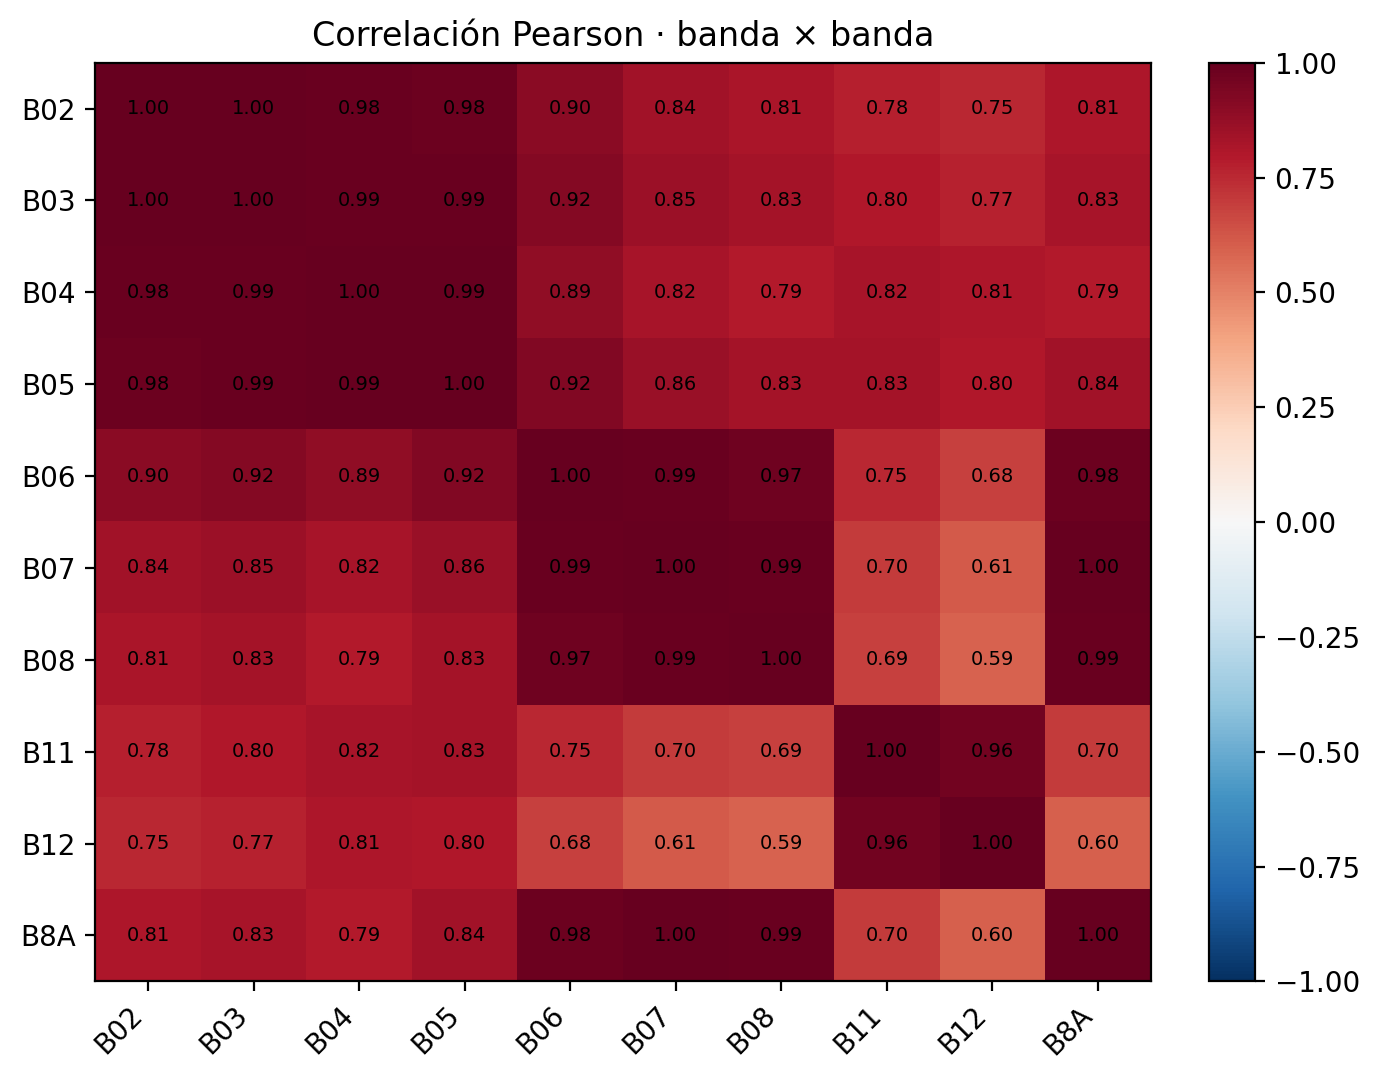

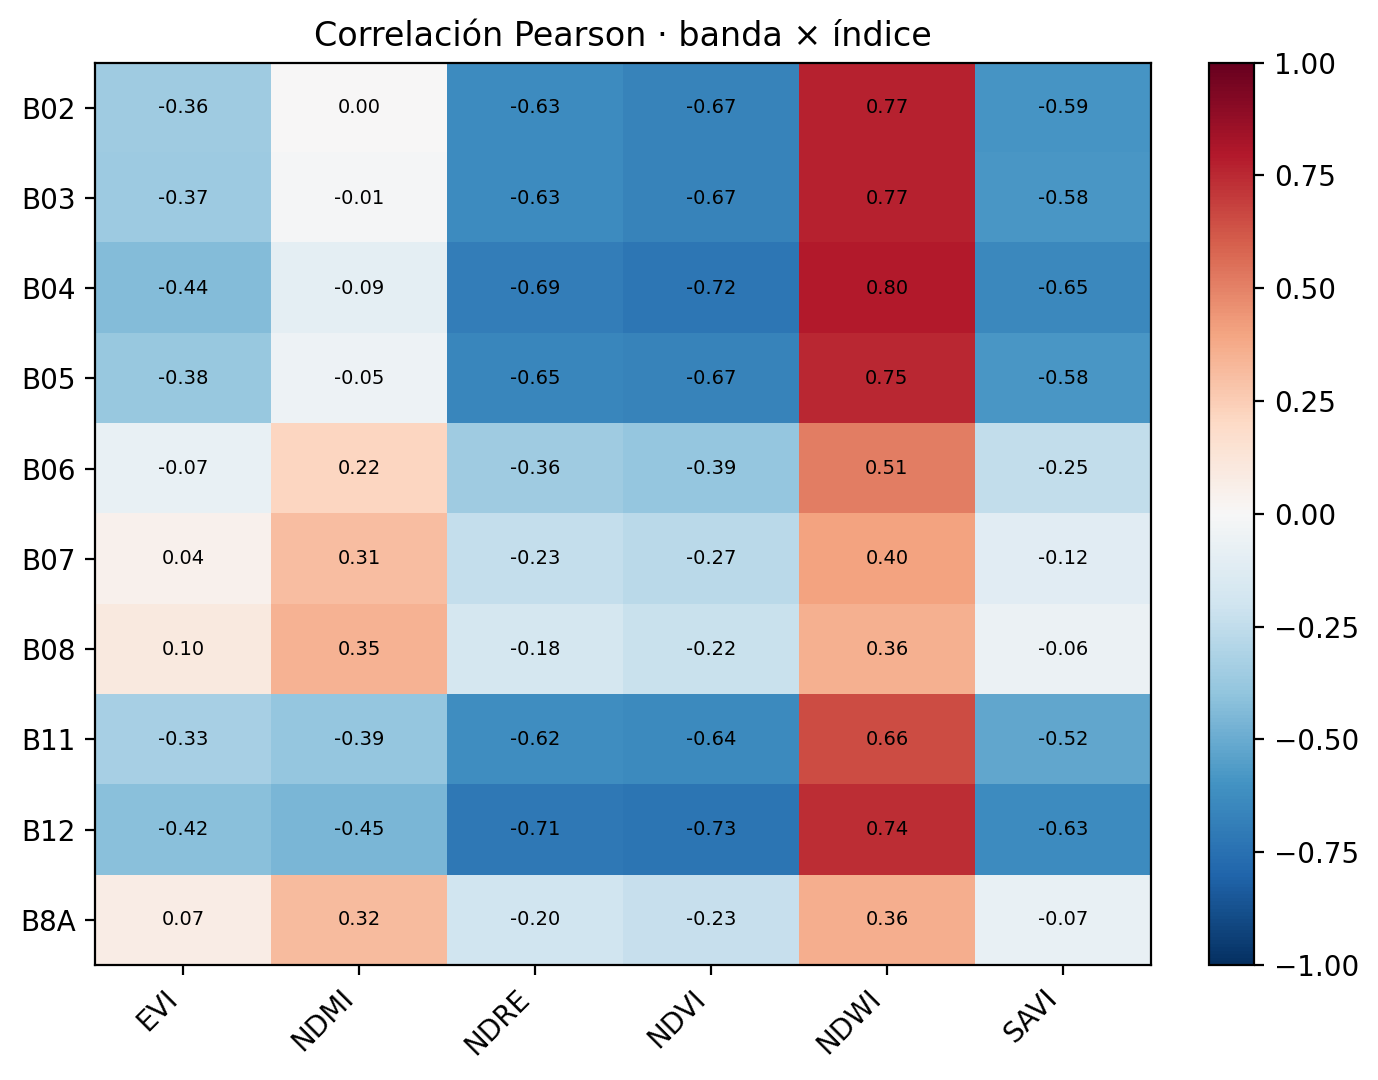

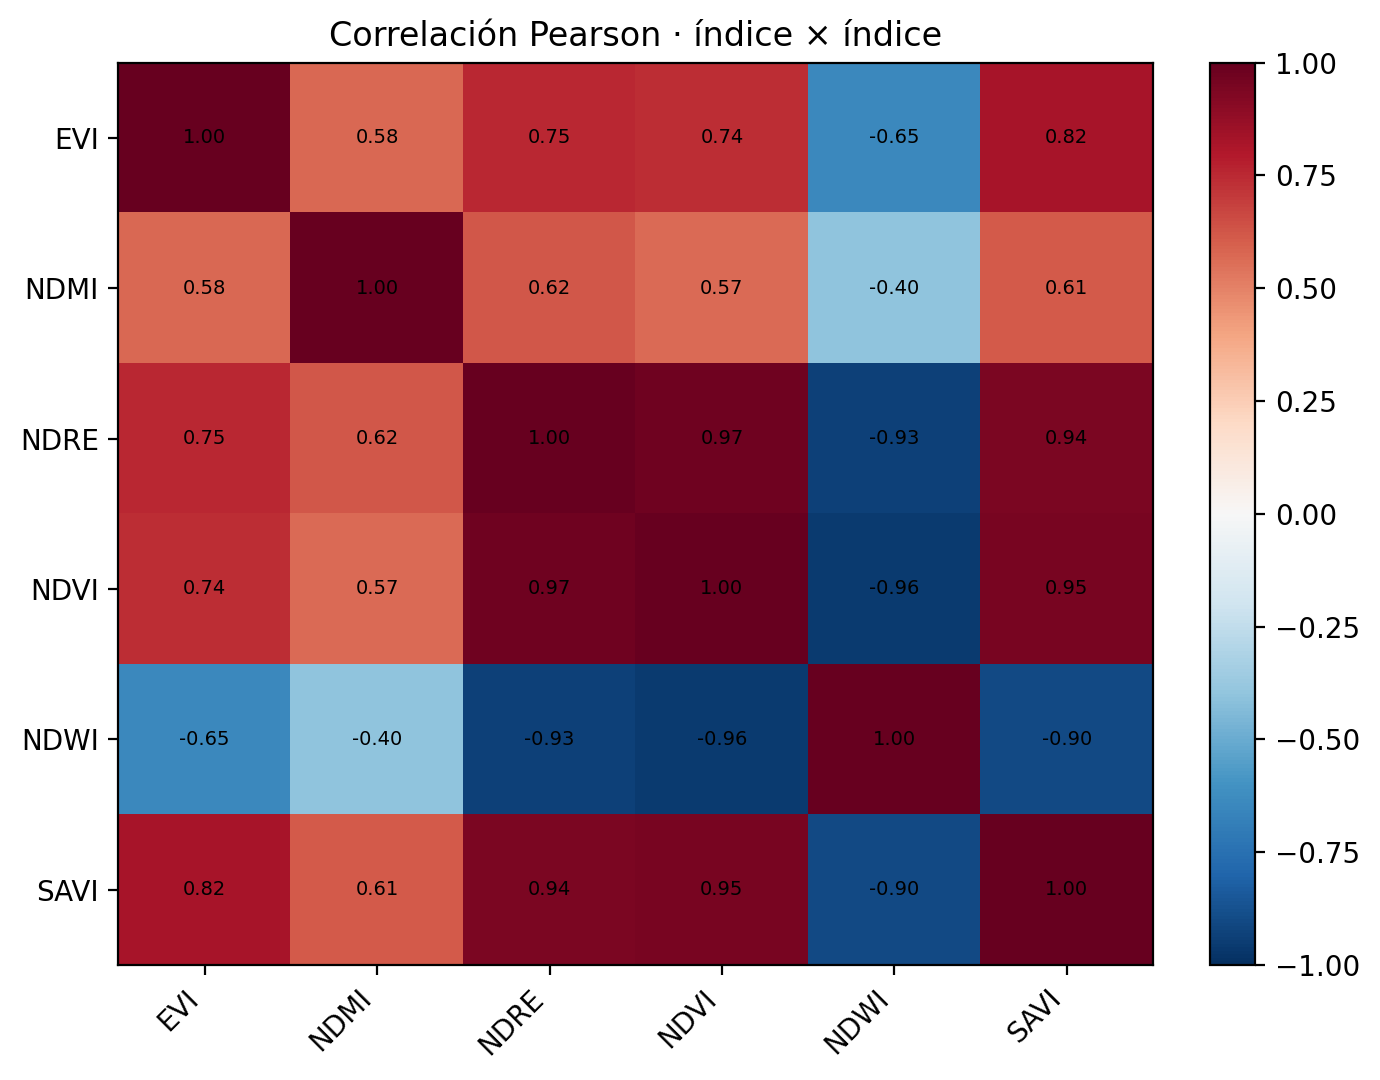

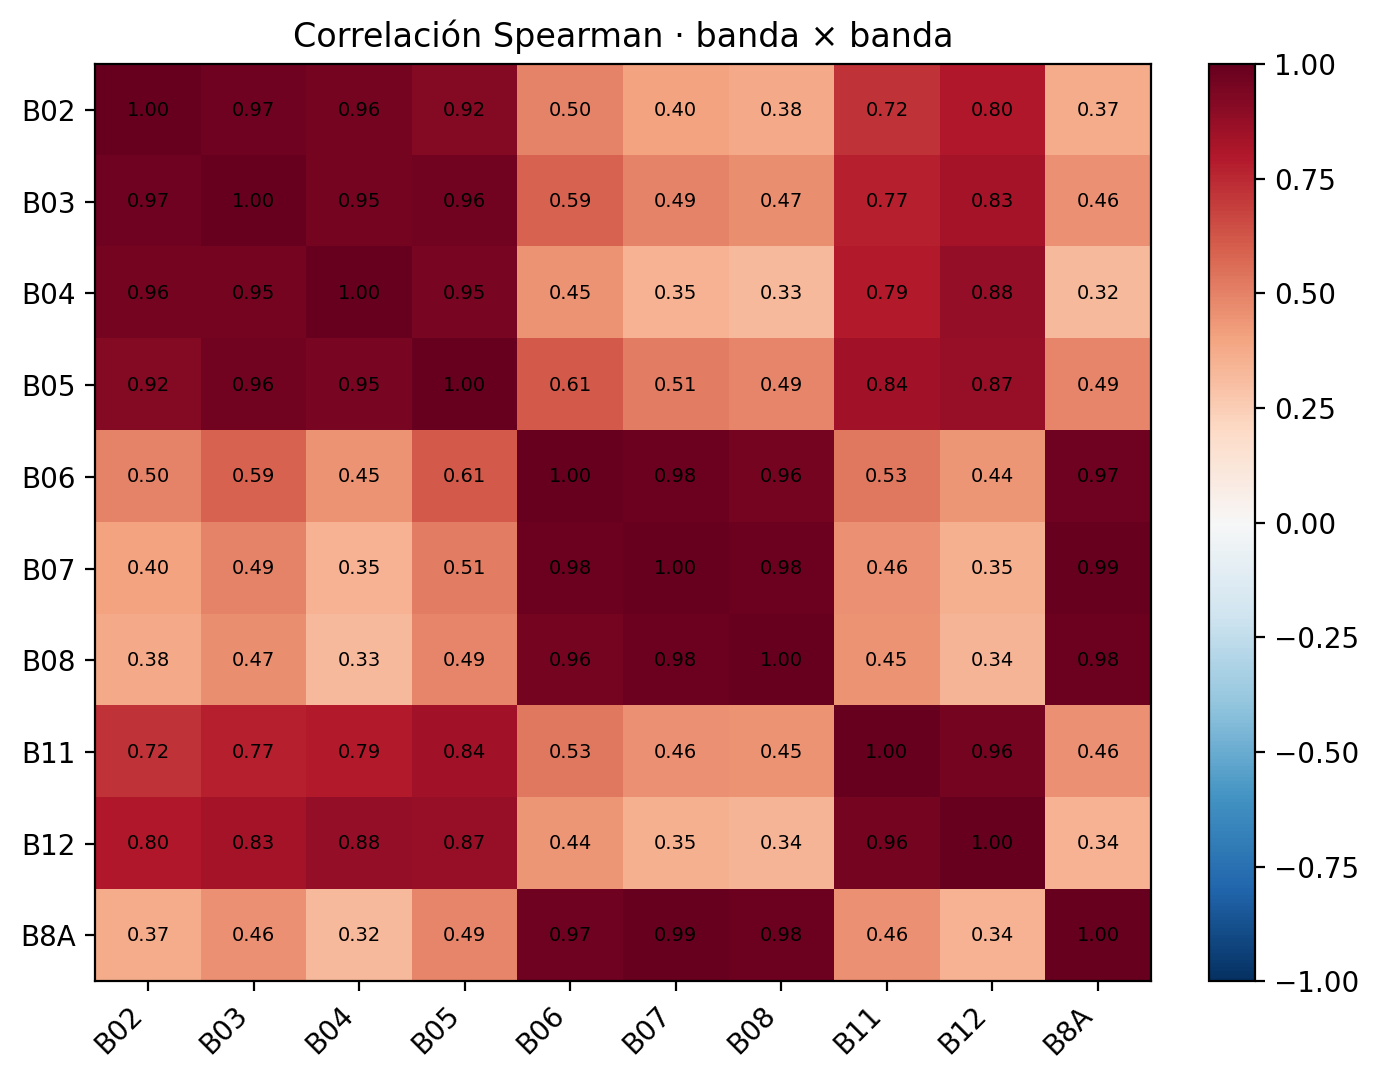

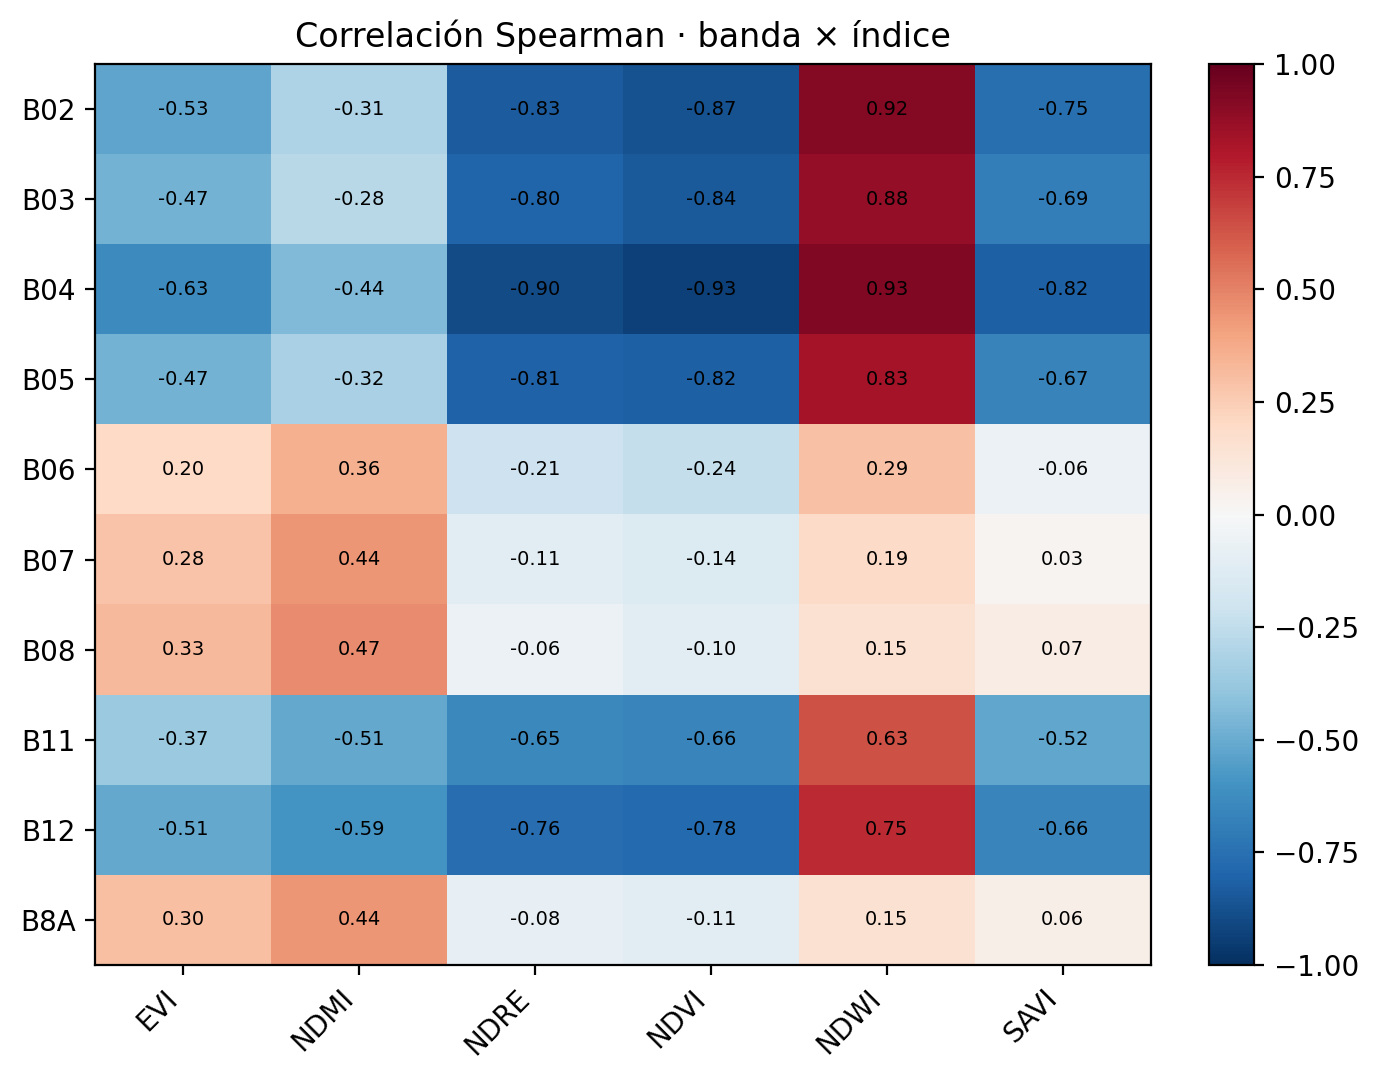

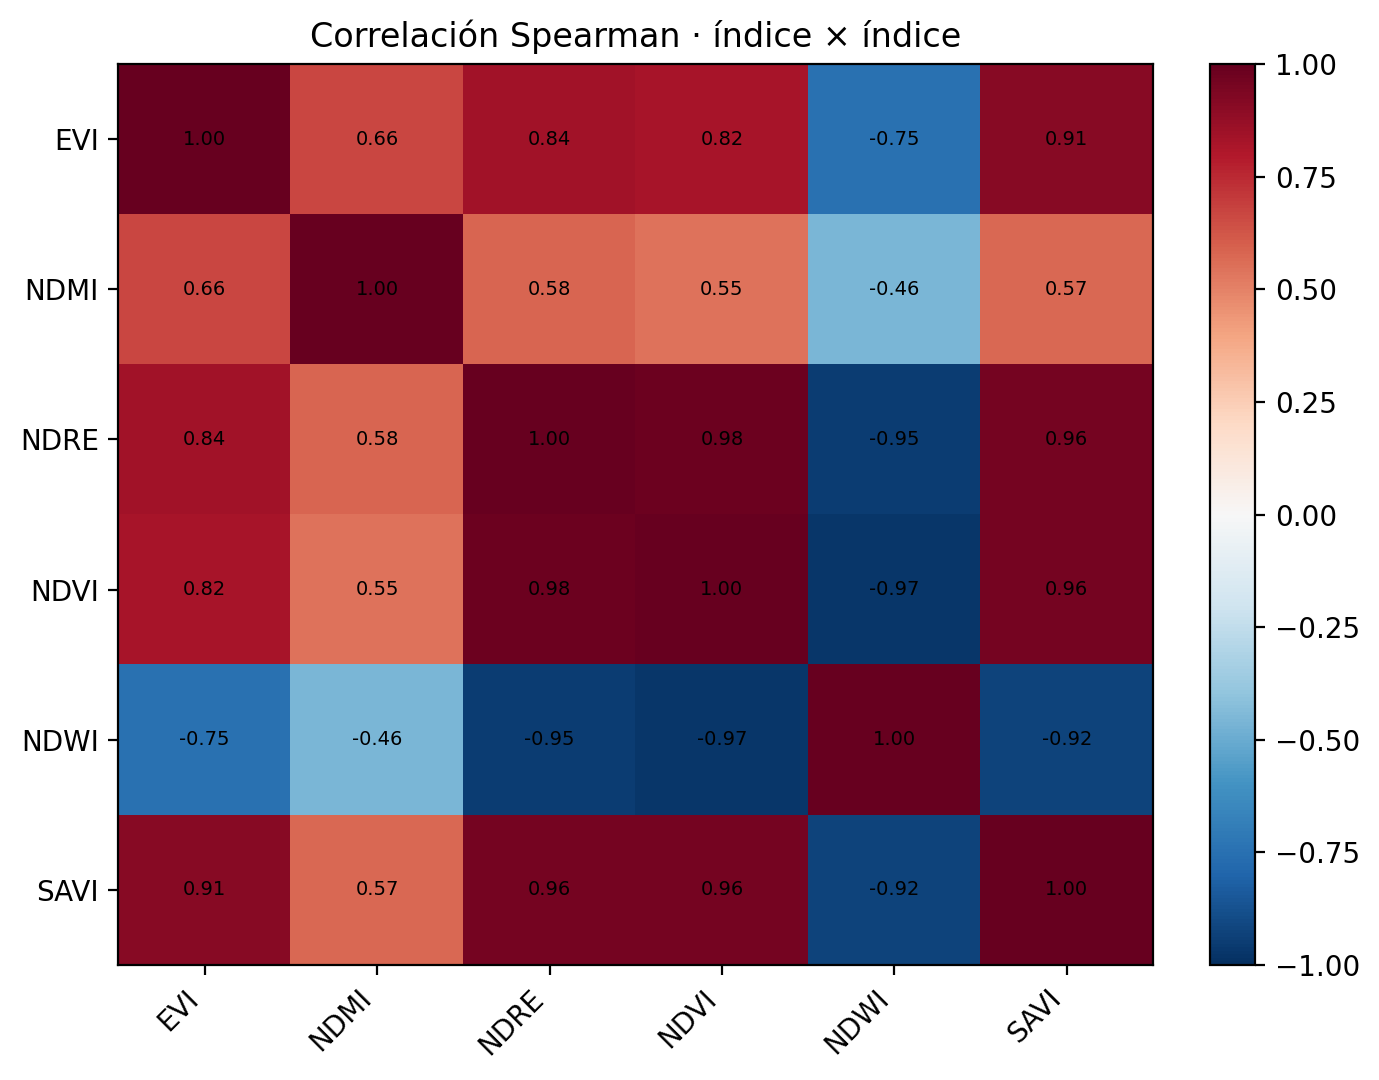

In [9]:
# Heatmap auxiliar long-form: correlation_heatmap del modulo ml/ esta disenado
# para matriz cuadrada con threshold de filtrado, no para tres bloques
# heterogeneos en escala consistente. Helper local; si aparece en otro notebook
# se sube a ml/analysis/visualization.py.
def _plot_pair_heatmap(df_corr: pl.DataFrame, title: str, out_path: Path) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(7, 5.5), dpi=200)
    if df_corr.is_empty():
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center")
    else:
        rows = sorted(set(df_corr["feature_a"].to_list()))
        cols = sorted(set(df_corr["feature_b"].to_list()))
        ri = {r: i for i, r in enumerate(rows)}
        ci = {c: j for j, c in enumerate(cols)}
        mat = np.full((len(rows), len(cols)), np.nan, dtype=np.float64)
        for r in df_corr.iter_rows(named=True):
            mat[ri[r["feature_a"]], ci[r["feature_b"]]] = r["corr"]
        im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
        ax.set_xticks(range(len(cols)))
        ax.set_xticklabels(cols, rotation=45, ha="right")
        ax.set_yticks(range(len(rows)))
        ax.set_yticklabels(rows)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="black")
        fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title)
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    return fig


heatmap_blocks: list[tuple[pl.DataFrame, str, str]] = [
    (corr_bb_pearson, "Correlación Pearson · banda × banda", "sec3_corr_pearson_bands_bands.png"),
    (corr_bi_pearson, "Correlación Pearson · banda × índice", "sec3_corr_pearson_bands_indices.png"),
    (corr_ii_pearson, "Correlación Pearson · índice × índice", "sec3_corr_pearson_indices_indices.png"),
    (corr_bb_spearman, "Correlación Spearman · banda × banda", "sec3_corr_spearman_bands_bands.png"),
    (corr_bi_spearman, "Correlación Spearman · banda × índice", "sec3_corr_spearman_bands_indices.png"),
    (corr_ii_spearman, "Correlación Spearman · índice × índice", "sec3_corr_spearman_indices_indices.png"),
]
for df_corr, title, fname in heatmap_blocks:
    fig = _plot_pair_heatmap(df_corr, title, FIGURES / fname)
    display(fig)
    plt.close(fig)

## Sección 4 — VIF: detección de multicolinealidad

VIF (Variance Inflation Factor) mide cuánto se infla la varianza estimada de un coeficiente cuando una feature es predecible a partir de las demás. Se aplica sobre el conjunto bandas + índices, con un pre-filtro que descarta features con correlación casi perfecta (`|r| > 0.99`) para evitar matrices singulares.

Convención estándar: `VIF > 5` es señal de advertencia, `VIF > 10` justifica eliminar la feature.

**Tabla VIF por feature (ordenada por VIF descendente):**

feature,vif,status
str,f64,str
"""B03""",inf,"""dropped_near_perfect_corr"""
"""B05""",inf,"""dropped_near_perfect_corr"""
"""B8A""",inf,"""dropped_near_perfect_corr"""
"""B06""",1149.142957,"""drop"""
"""B07""",865.751496,"""drop"""
"""B08""",792.997976,"""drop"""
"""B04""",509.630929,"""drop"""
"""SAVI""",446.50249,"""drop"""
"""NDVI""",279.663157,"""drop"""


**Features marcadas para descarte**: `16`

**Variance Inflation Factor por feature**

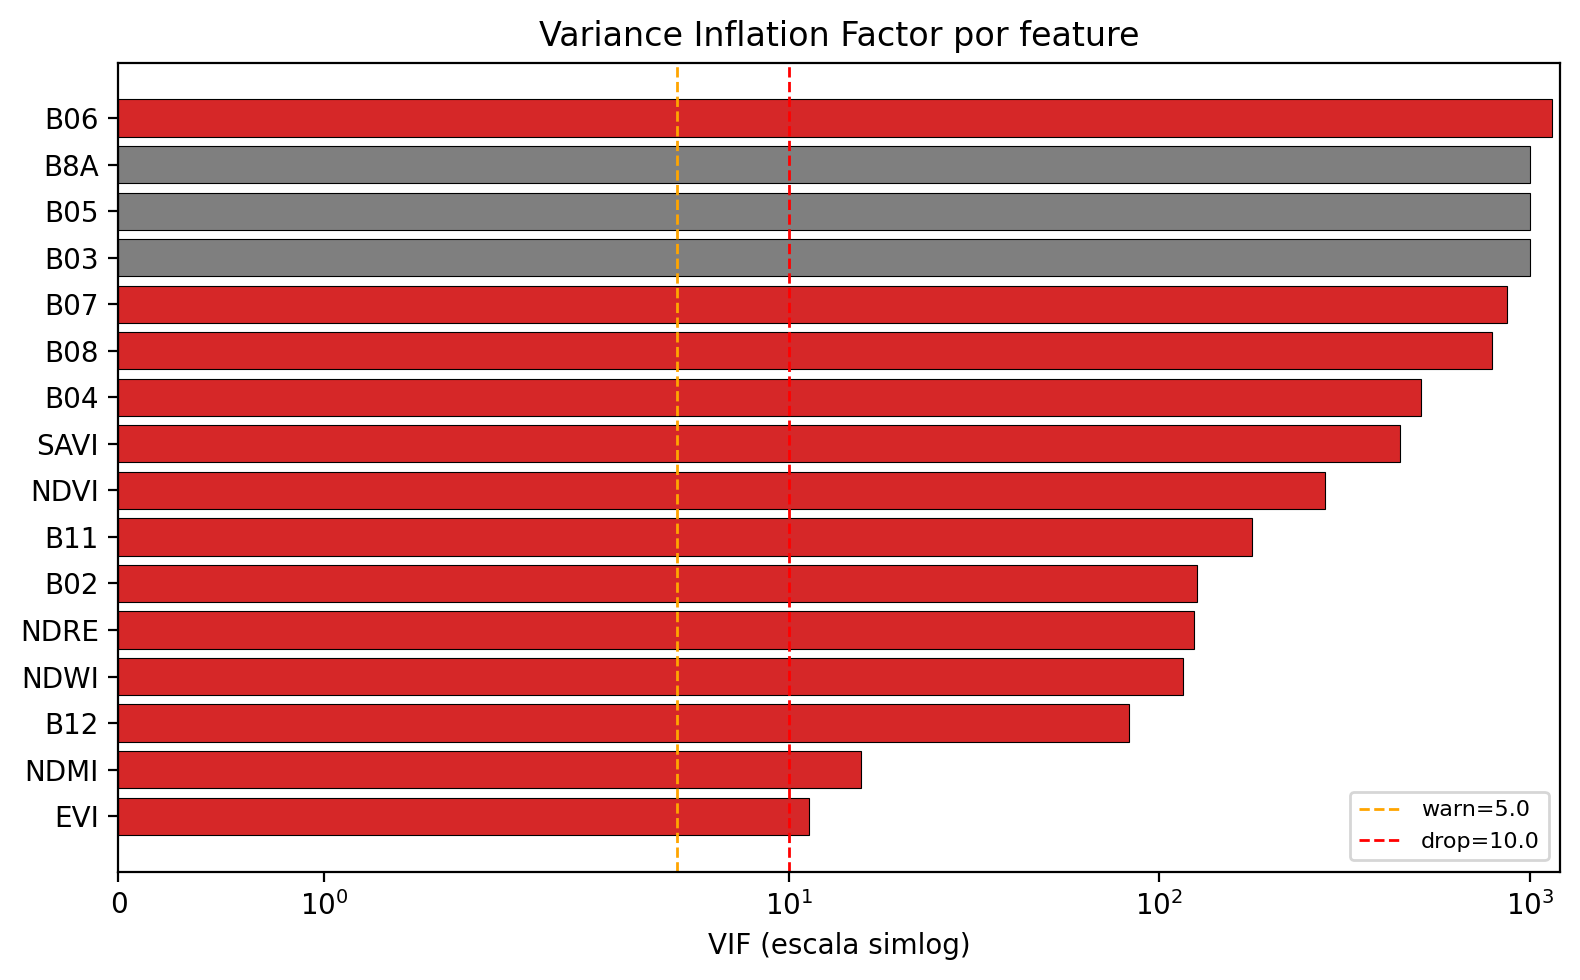

In [10]:
vif_cols = [c for c in PASTIS_S2_BANDS if c in df_idx.columns] + indices_present
if not df_idx.is_empty() and vif_cols:
    vif_df = vif_table(df_idx, cols=vif_cols)
    display(Markdown("**Tabla VIF por feature (ordenada por VIF descendente):**"))
    display(vif_df)
    to_drop = vif_df.filter(pl.col("status").is_in(["drop", "dropped_near_perfect_corr"]))
    display(Markdown(f"**Features marcadas para descarte**: `{to_drop.height}`"))
else:
    vif_df = pl.DataFrame()
vif_barplot(vif_df, out_path=FIGURES / "sec4_vif_barplot.png")
show_saved_png(FIGURES / "sec4_vif_barplot.png", caption="Variance Inflation Factor por feature")

## Sección 5 — Pairplot top-5 features por clase

Visualización pareada de las cinco features más discriminativas (NDVI, NDWI, NDMI, NDRE, EVI) coloreadas por clase de cultivo. Para mantener el plot legible se limita a las diez clases más frecuentes y se submuestrean 2 000 puntos por clase. La diagonal muestra la densidad por clase y permite leer rápidamente qué cultivos se solapan y cuáles se separan limpiamente.

**Features usadas en el pairplot**: `['NDVI', 'NDWI', 'NDMI', 'NDRE', 'EVI']`

**Pairplot de features espectrales coloreado por clase de cultivo**

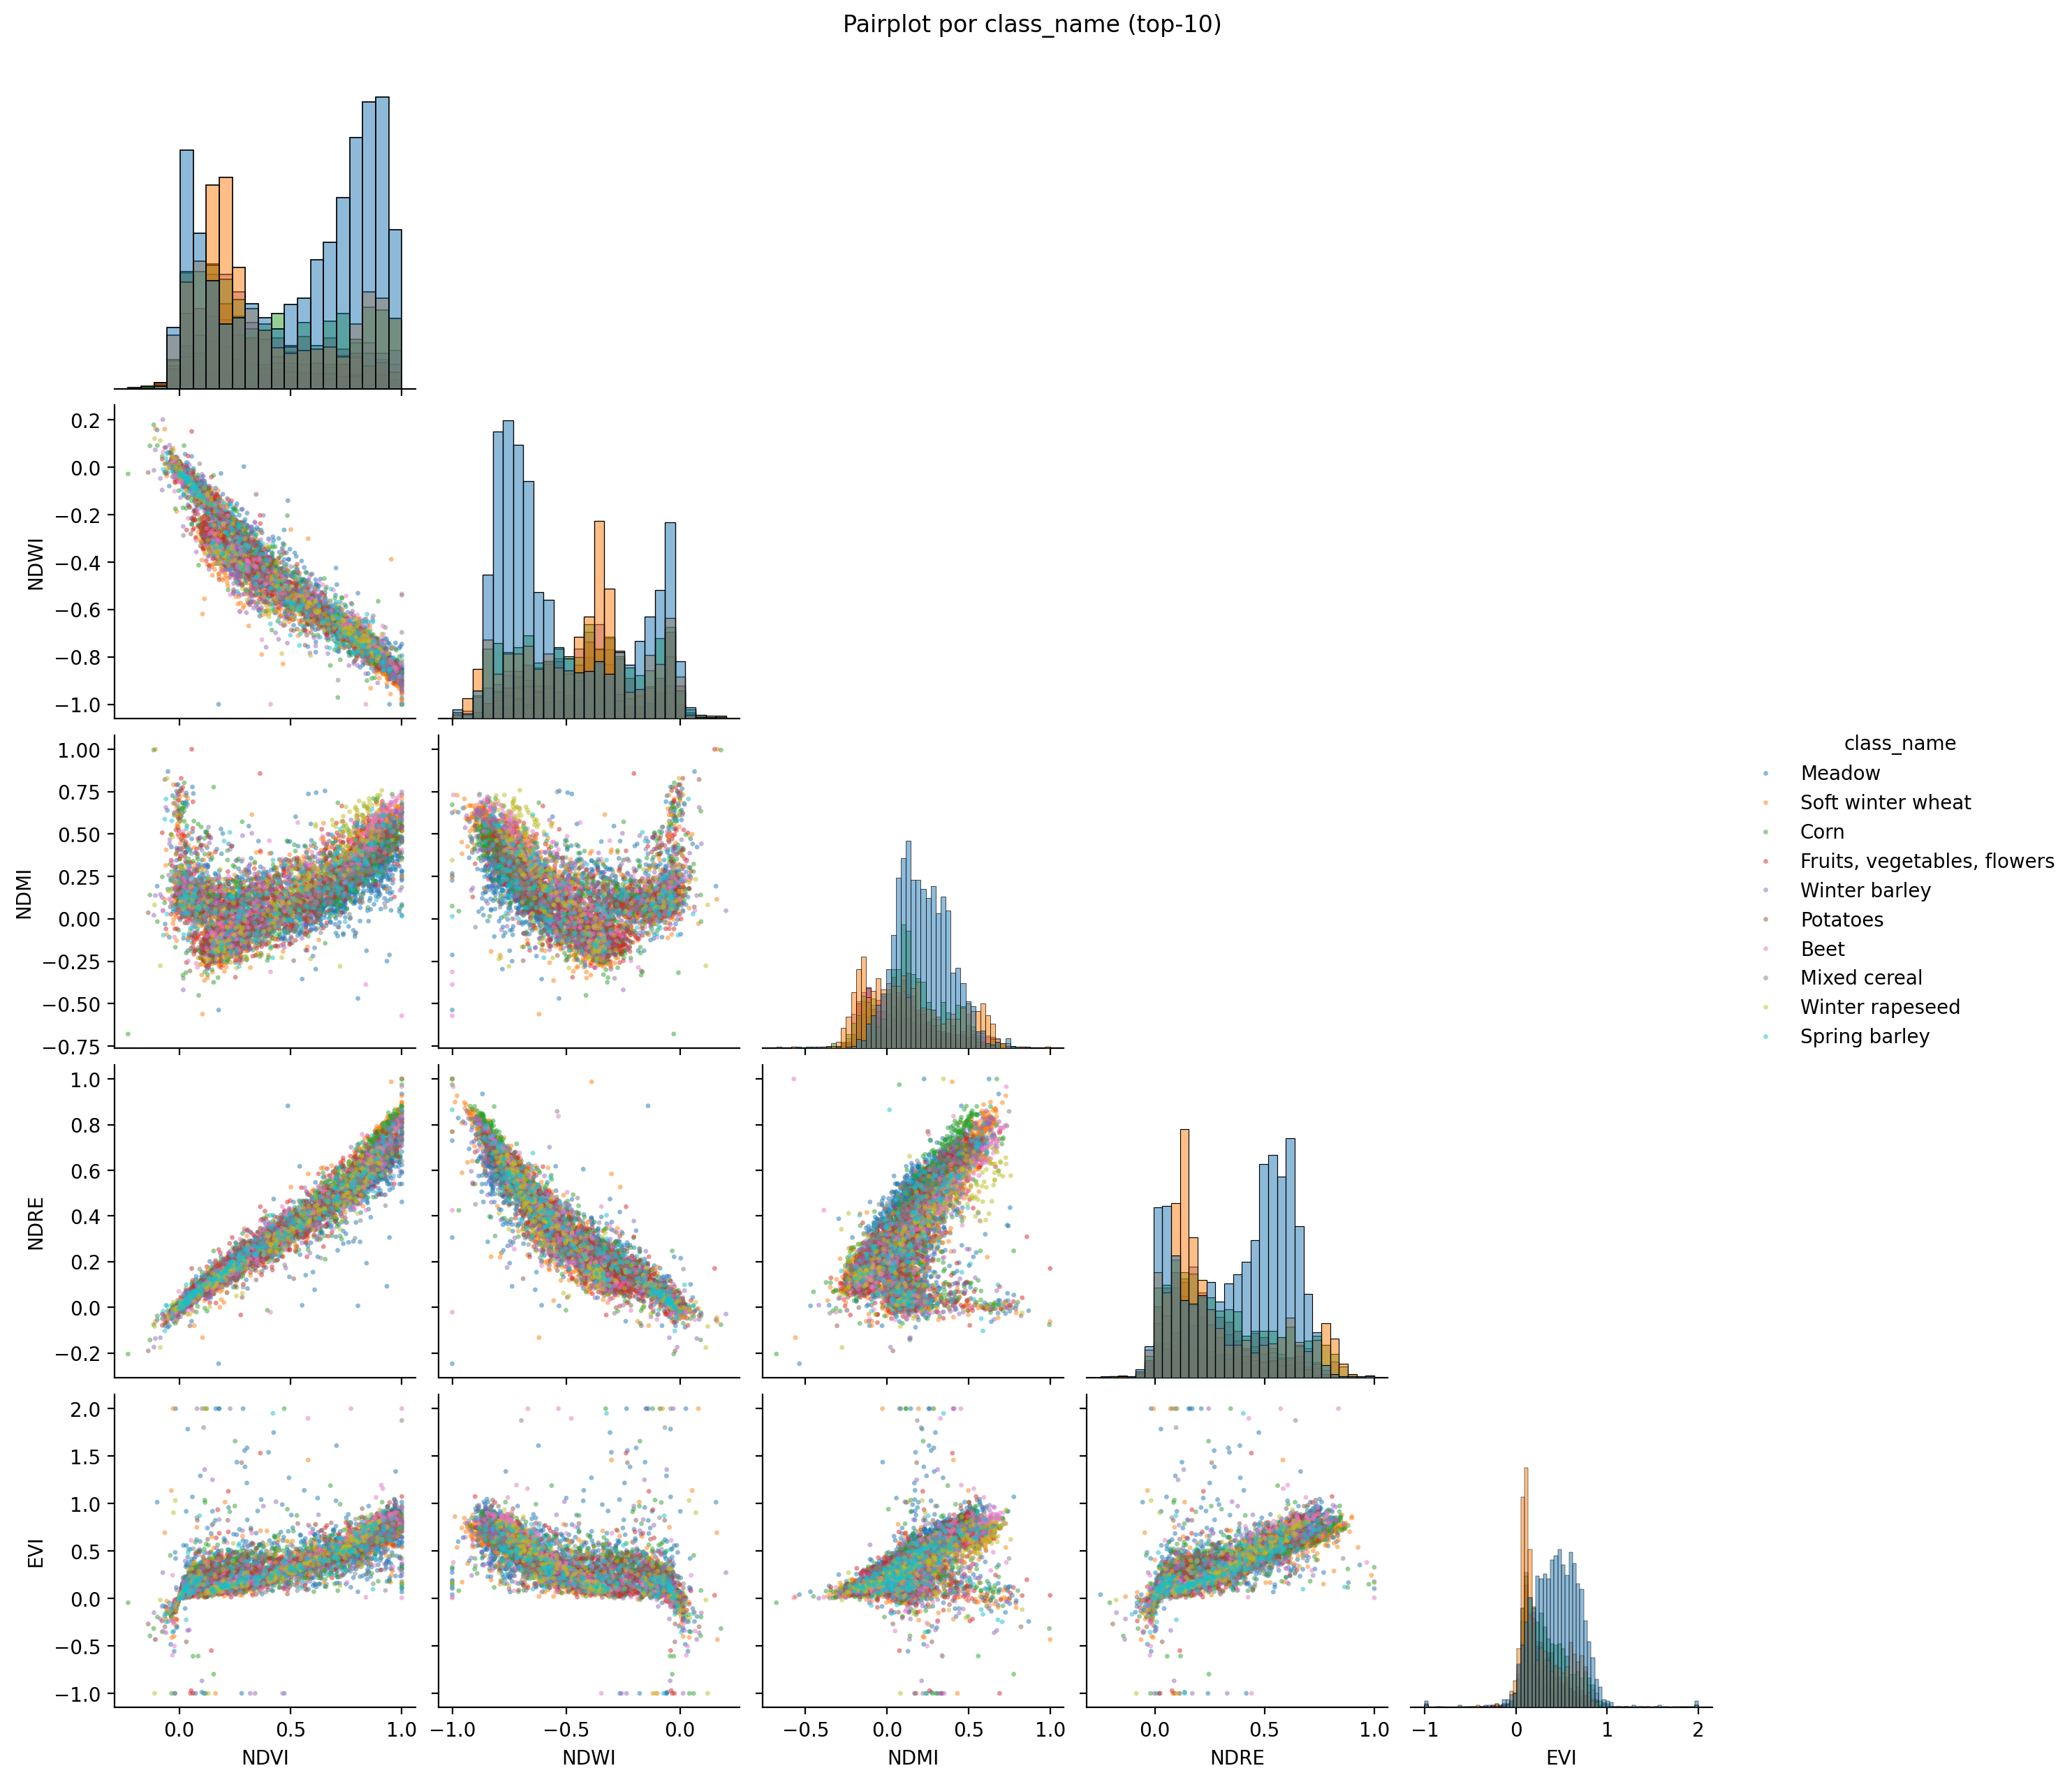

In [11]:
top5_features = [f for f in ["NDVI", "NDWI", "NDMI", "NDRE", "EVI"] if f in df_idx.columns]
pairplot_by_class(
    df=df_idx,
    features=top5_features,
    class_col="class_name",
    out_path=FIGURES / "sec5_pairplot_top5_by_class.png",
    subsample_per_class=2000,
    top_classes=10,
    seed=seed,
)
display(Markdown(f"**Features usadas en el pairplot**: `{top5_features}`"))
show_saved_png(
    FIGURES / "sec5_pairplot_top5_by_class.png",
    caption="Pairplot de features espectrales coloreado por clase de cultivo",
)

## Sección 6 — Pico NDVI por clase y mes en que ocurre

Para cada parcela-pixel localizamos el día del año en que NDVI alcanza su máximo. Esto da dos features fenológicas: el **valor del pico** (cuán vigoroso llega a estar el cultivo) y el **mes del pico** (cuándo lo alcanza). Los boxplot y violin plot agrupados por clase revelan el calendario agrícola: trigo de invierno picando en mayo-junio, maíz en agosto, etc.

In [12]:
if not df_idx.is_empty() and "NDVI" in df_idx.columns:
    df_ts = df_idx.rename({"NDVI": "ndvi", "date_parsed": "date_d"}).filter(
        pl.col("class_id").is_between(1, 18)
    )
    df_peaks = phenology_peaks(df_ts, parcel_col="parcel_id", date_col="date_d", ndvi_col="ndvi", class_col="class_name")
    display(Markdown(f"**Picos detectados**: `{df_peaks.height:,}` parcelas-pixel"))
    display(Markdown("**Primeras filas de la tabla de picos (valor y mes del pico por parcela):**"))
    display(df_peaks.head(8))
else:
    df_peaks = pl.DataFrame()

**Picos detectados**: `200` parcelas-pixel

**Primeras filas de la tabla de picos (valor y mes del pico por parcela):**

parcel_id,class_name,peak_ndvi_value,peak_ndvi_month,peak_ndvi_doy,peak_ndvi_year
str,str,f64,i64,i64,i64
"""10028_104_40""","""Meadow""",1.0,3,72,2019
"""10006_72_120""","""Meadow""",1.0,9,267,2018
"""10018_8_16""","""Meadow""",0.941395,4,112,2019
"""10006_56_88""","""Meadow""",1.0,9,267,2018
"""10013_8_8""","""Spring barley""",0.962678,10,292,2019
"""10013_32_56""","""Corn""",0.967267,9,257,2019
"""10014_16_32""","""Corn""",1.0,7,212,2019
"""10021_40_48""","""Fruits, vegetables, flowers""",1.0,10,292,2019


C:\Users\arthu\AppData\Local\Temp\ipykernel_17456\1898907791.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_box, vert=False, labels=classes_order, showfliers=False)


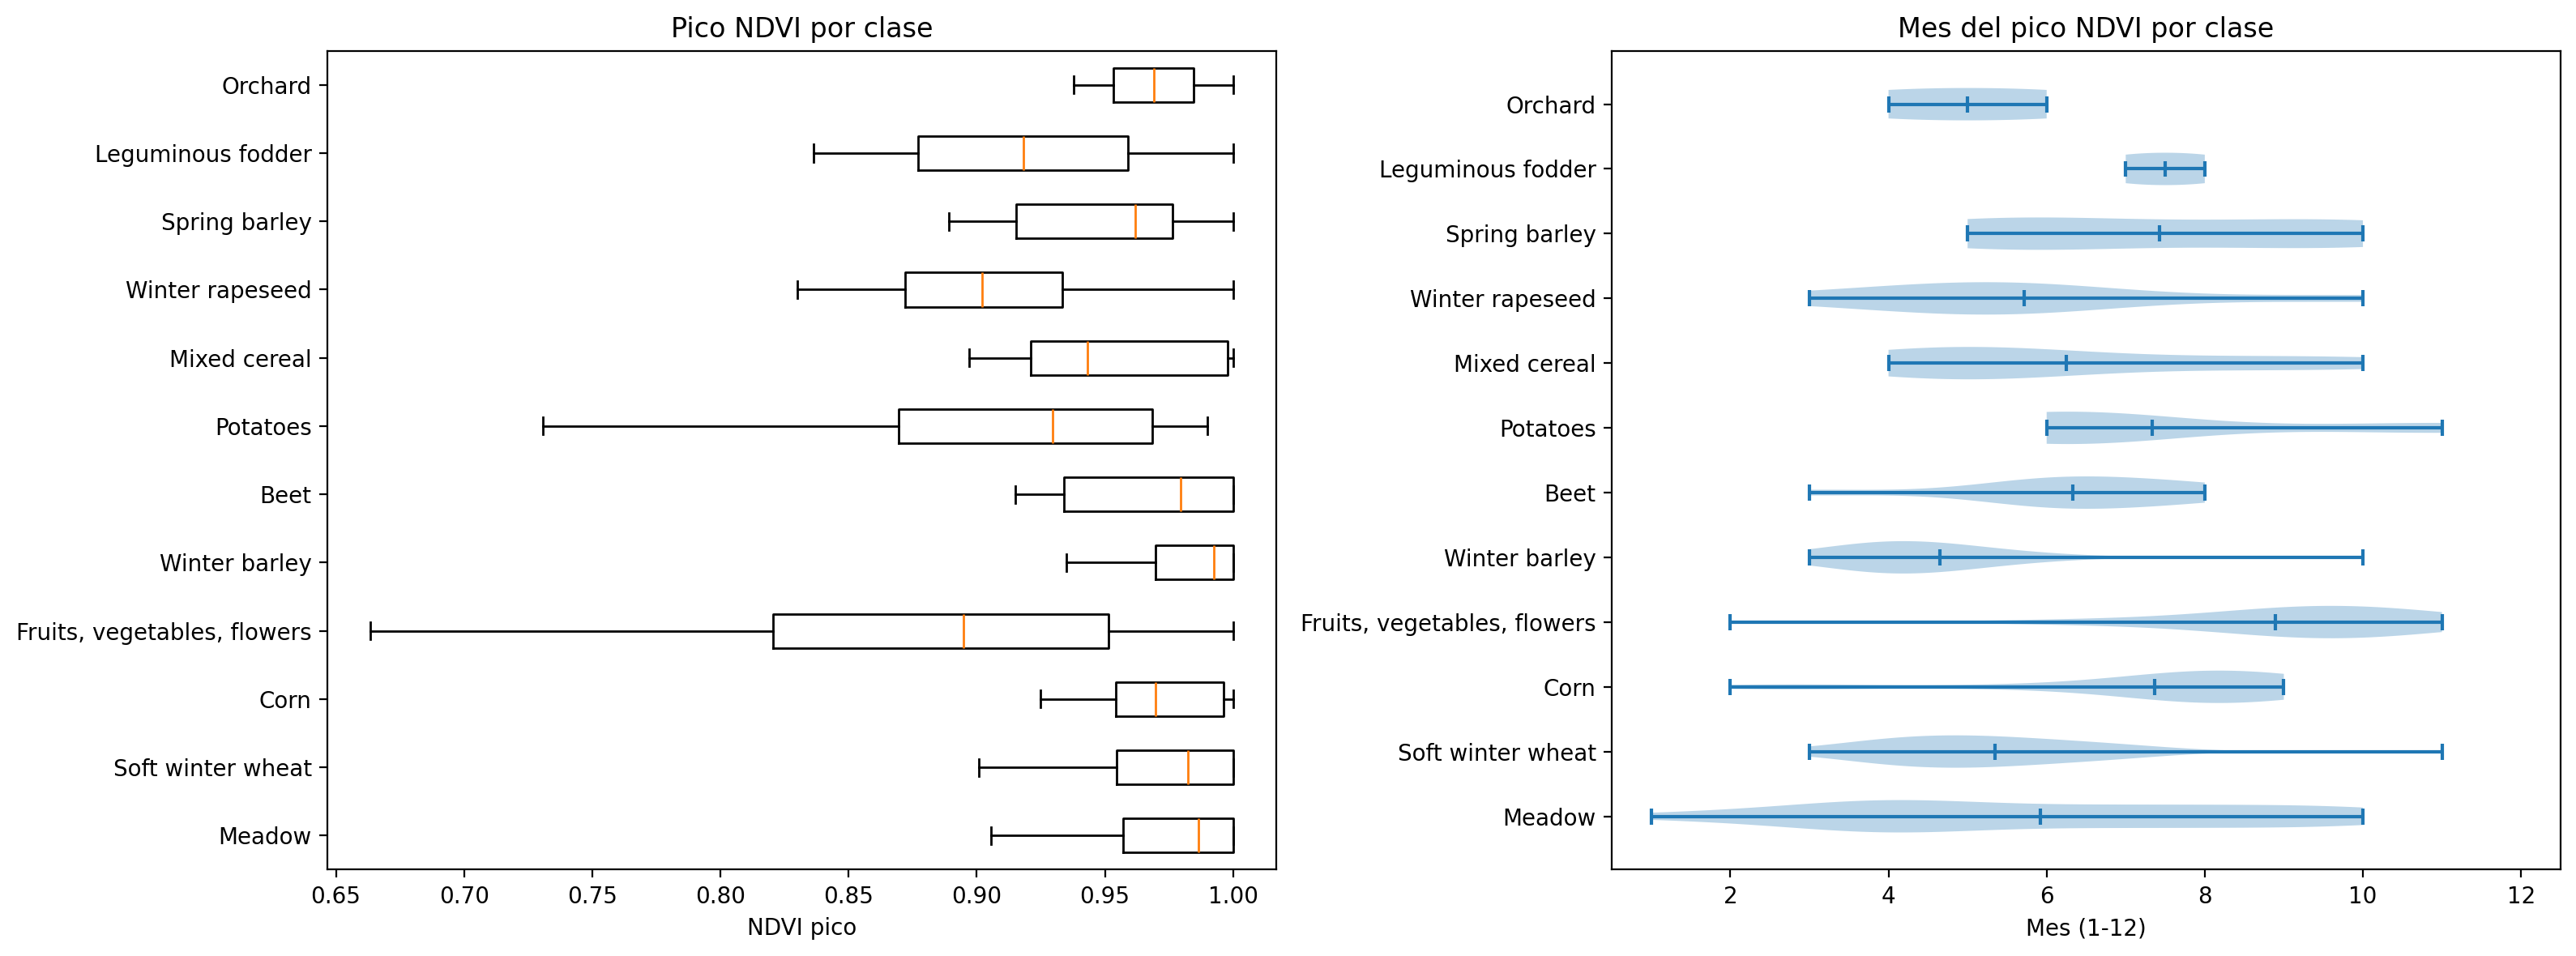

In [13]:
# Box NDVI peak por clase + violin mes pico
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=200)
if not df_peaks.is_empty():
    pdf = df_peaks.to_pandas()
    classes_order = (
        df_peaks.group_by("class_name").agg(pl.len().alias("n")).sort("n", descending=True)["class_name"].to_list()
    )
    data_box = [pdf.loc[pdf["class_name"] == c, "peak_ndvi_value"].dropna().to_numpy() for c in classes_order]
    axes[0].boxplot(data_box, vert=False, labels=classes_order, showfliers=False)
    axes[0].set_title("Pico NDVI por clase")
    axes[0].set_xlabel("NDVI pico")
    data_violin = [pdf.loc[pdf["class_name"] == c, "peak_ndvi_month"].dropna().to_numpy() for c in classes_order]
    valid = [d for d in data_violin if d.size > 0]
    if valid:
        axes[1].violinplot(valid, vert=False, showmeans=True)
        axes[1].set_yticks(np.arange(1, len(classes_order) + 1))
        axes[1].set_yticklabels(classes_order)
        axes[1].set_title("Mes del pico NDVI por clase")
        axes[1].set_xlabel("Mes (1-12)")
        axes[1].set_xlim(0.5, 12.5)
else:
    for ax in axes:
        ax.text(0.5, 0.5, "Sin datos PASTIS-R", ha="center", va="center")
fig.tight_layout()
fig.savefig(FIGURES / "sec6_peak_ndvi_by_class.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

## Sección 7 — Autocorrelación temporal (ACF/PACF)

ACF mide cuán parecida es la serie a versiones desplazadas de sí misma; PACF aísla la dependencia directa quitando el efecto de los lags intermedios. Antes del cálculo, las series PASTIS (medidas a un ritmo irregular, ~5 días entre observaciones) se resamplean a paso mensual con interpolación lineal.

Cobertura temporal real del dataset: aproximadamente 14 meses, por lo que el lag máximo se limita a 6 — más lags dejarían demasiado pocas observaciones por punto. **Test de significancia**: la banda de Bartlett `±1.96/√n` con `n ≈ 14` da un umbral de `~0.524`. Reportamos el porcentaje de pares `(parcela, lag)` que superan ese umbral, separado por lag, para cuantificar cuánta señal autocorrelativa tiene PASTIS en este horizonte.

**Filas ACF/PACF**: `1,400`

**Primeras filas (lag × parcela × clase con ACF y PACF):**

parcel_id,class_name,lag,acf,pacf
str,str,i64,f64,f64
"""10000_0_112""","""Fruits, vegetables, flowers""",0,1.0,1.0
"""10000_0_112""","""Fruits, vegetables, flowers""",1,0.157623,0.157623
"""10000_0_112""","""Fruits, vegetables, flowers""",2,0.031511,0.006835
"""10000_0_112""","""Fruits, vegetables, flowers""",3,-0.061089,-0.068812
"""10000_0_112""","""Fruits, vegetables, flowers""",4,0.120824,0.144986
"""10000_0_112""","""Fruits, vegetables, flowers""",5,0.107847,0.072227
"""10000_0_112""","""Fruits, vegetables, flowers""",6,0.013702,-0.0286
"""10000_104_104""","""Fruits, vegetables, flowers""",0,1.0,1.0


**Significancia ACF por lag** (umbral Bartlett `±0.524` para n≈14 observaciones mensuales por parcela):

lag,n_pares,n_significativos,pct_significativos
i64,u32,u32,f64
1,200,44,22.0
2,200,1,0.5
3,200,10,5.0
4,200,16,8.0
5,200,5,2.5
6,200,2,1.0


**Pares (parcela, lag≥1) con `|ACF| > 0.524`**: `6.5%` del total

**ACF agregada por clase (media + IC 95%) hasta el lag máximo**

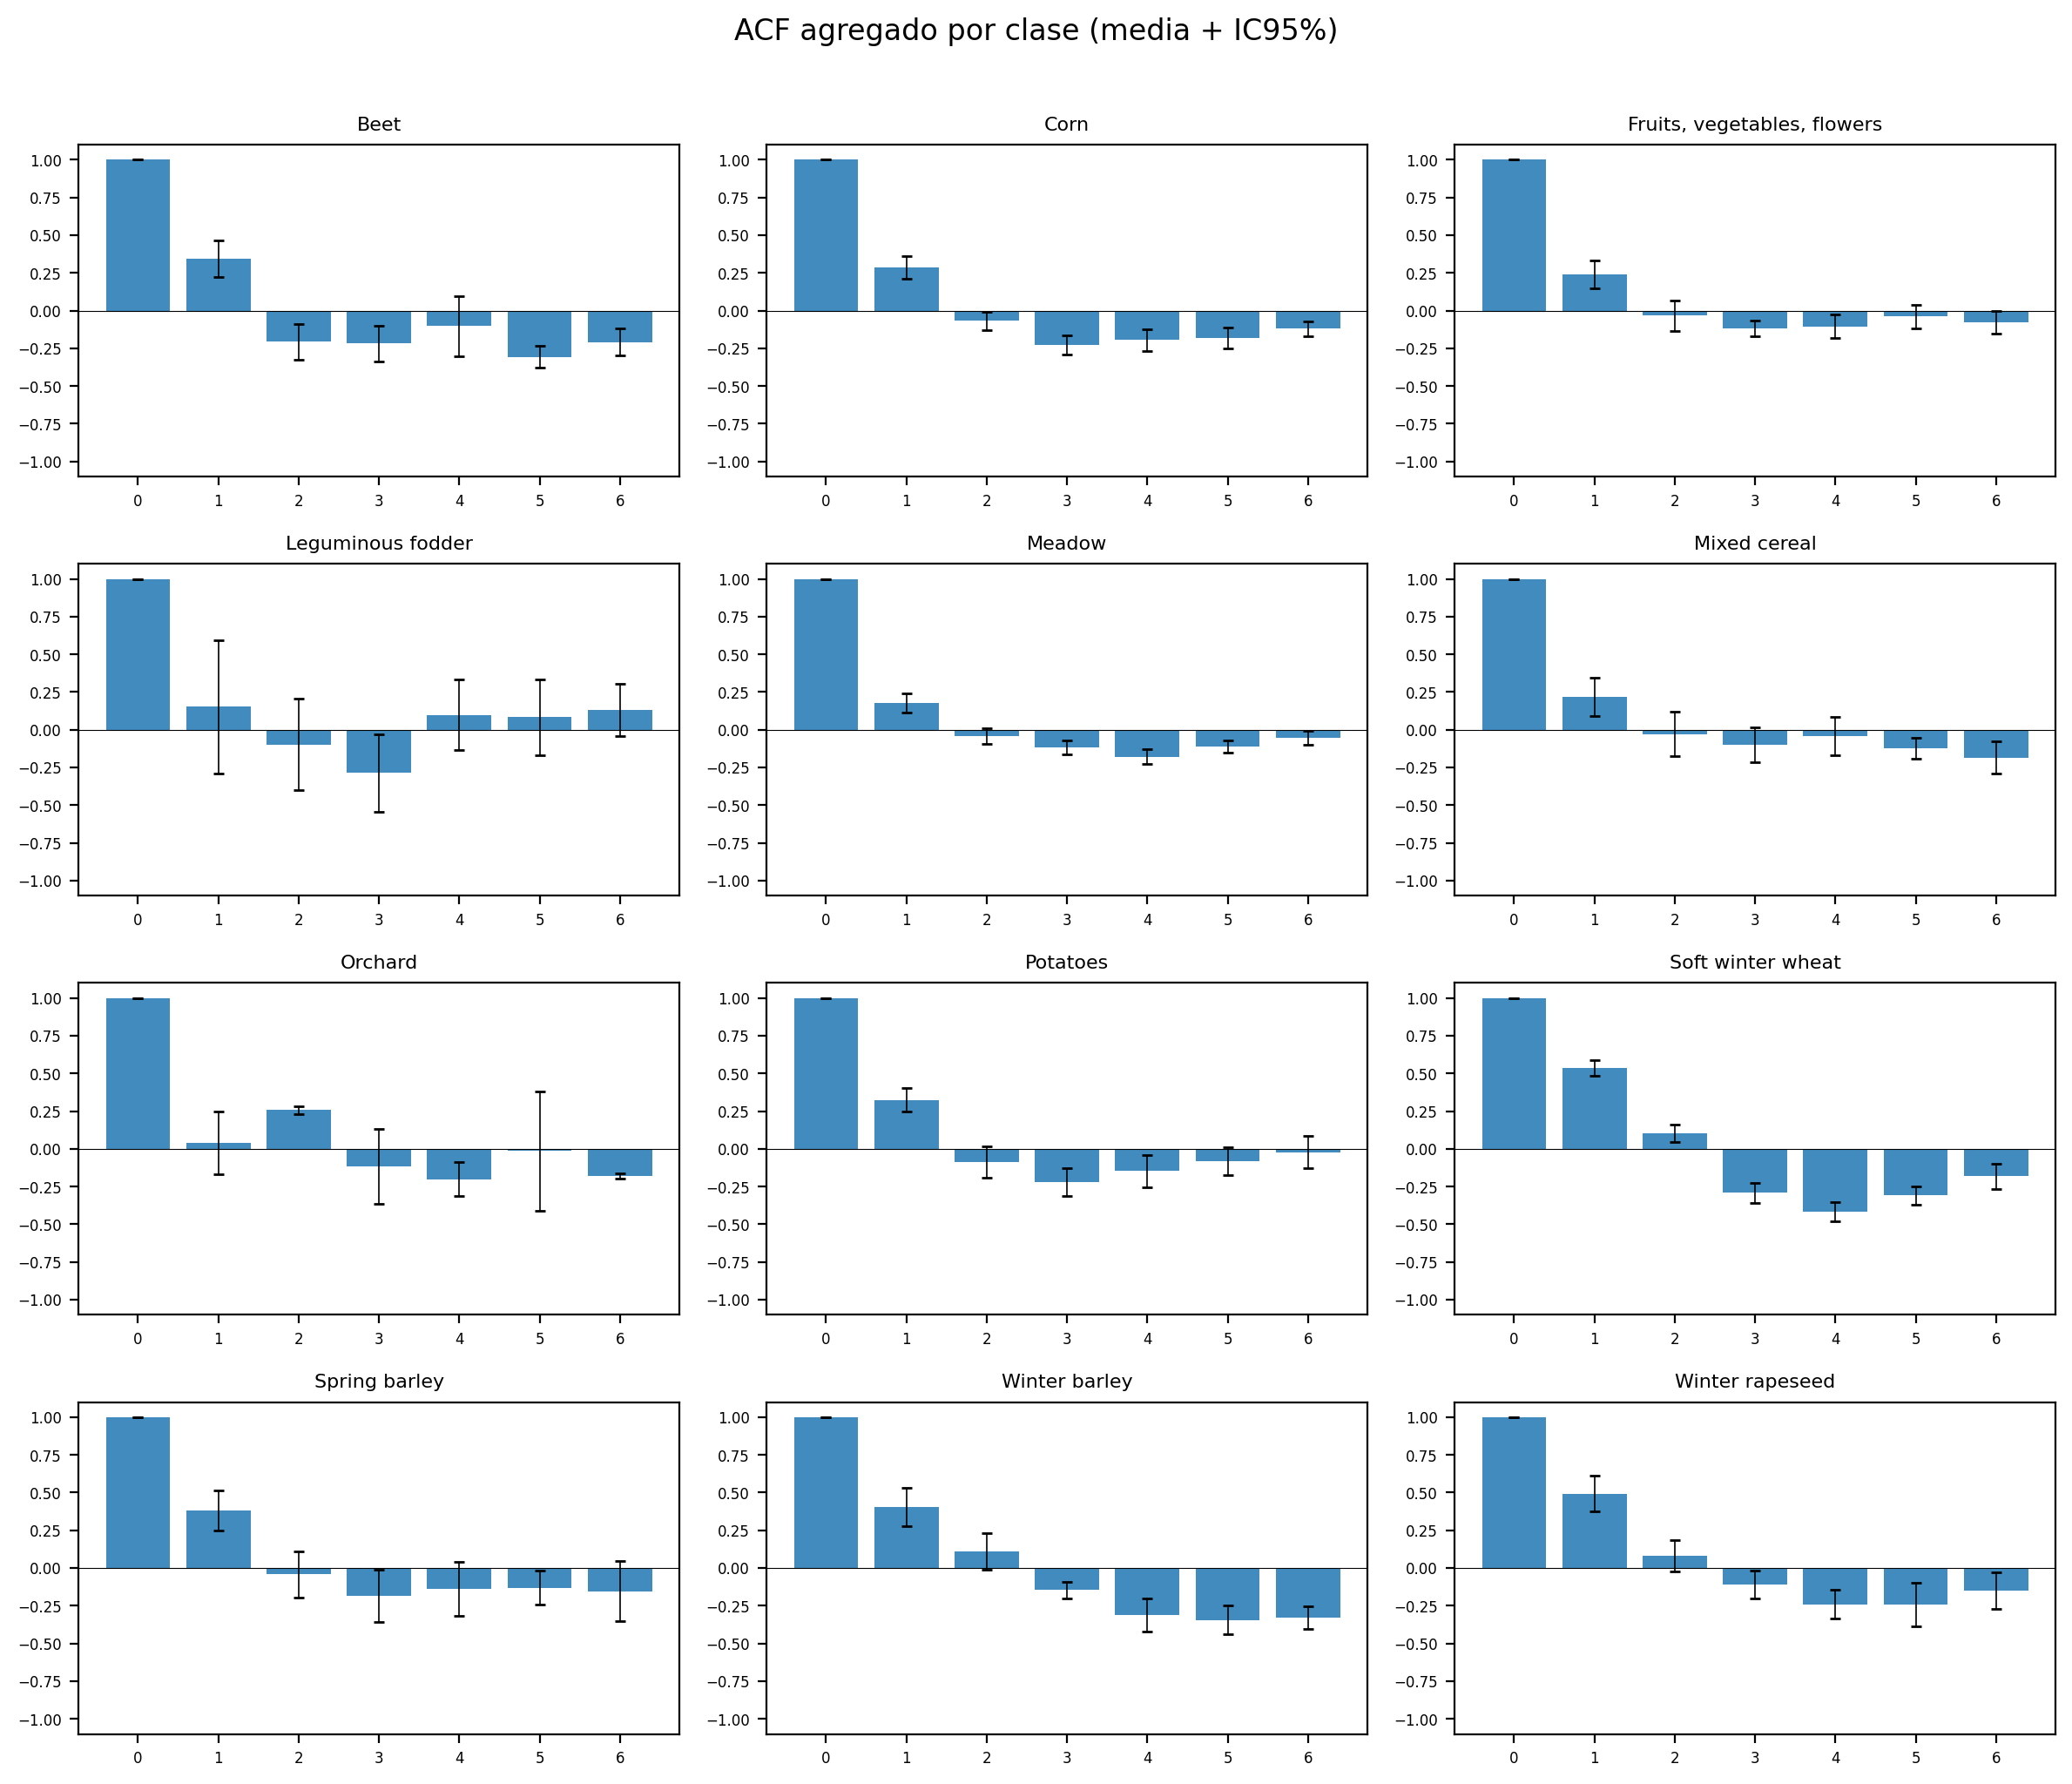

In [14]:
if not df_idx.is_empty() and "NDVI" in df_idx.columns:
    df_acf_input = df_idx.rename({"NDVI": "ndvi", "date_parsed": "date_d"})
    df_acf = acf_pacf_per_parcel(
        df_acf_input,
        max_lag=max_lag,
        parcel_col="parcel_id",
        date_col="date_d",
        series_col="ndvi",
        class_col="class_name",
    )
    display(Markdown(f"**Filas ACF/PACF**: `{df_acf.height:,}`"))
    display(Markdown("**Primeras filas (lag × parcela × clase con ACF y PACF):**"))
    display(df_acf.head(8))

    # Significancia: bandas de Bartlett ~ 1.96/sqrt(n_obs) con n_obs = numero de
    # puntos mensuales por parcela. PASTIS cubre ~14 meses tras el resampleo,
    # asi que el umbral es ~0.524. Reportamos % de pares (parcela, lag>=1) que
    # superan el umbral, separado por lag.
    n_obs_aprox = 14
    sig_threshold = 1.96 / (n_obs_aprox ** 0.5)
    df_acf_sig = (
        df_acf.filter(pl.col("lag") >= 1)
        .with_columns((pl.col("acf").abs() > sig_threshold).alias("is_significant"))
    )
    pct_by_lag = (
        df_acf_sig.group_by("lag")
        .agg([
            pl.len().alias("n_pares"),
            pl.col("is_significant").sum().alias("n_significativos"),
            (100 * pl.col("is_significant").sum() / pl.len()).alias("pct_significativos"),
        ])
        .sort("lag")
    )
    display(Markdown(
        f"**Significancia ACF por lag** (umbral Bartlett `±{sig_threshold:.3f}` "
        f"para n≈{n_obs_aprox} observaciones mensuales por parcela):"
    ))
    display(pct_by_lag)
    pct_global = 100 * df_acf_sig["is_significant"].sum() / df_acf_sig.height if df_acf_sig.height else 0.0
    display(Markdown(
        f"**Pares (parcela, lag≥1) con `|ACF| > {sig_threshold:.3f}`**: "
        f"`{pct_global:.1f}%` del total"
    ))
else:
    df_acf = pl.DataFrame()
    pct_global = 0.0
acf_grid_by_class(df_acf, out_path=FIGURES / "sec7_acf_grid_by_class.png", ncols=3)
show_saved_png(
    FIGURES / "sec7_acf_grid_by_class.png",
    caption="ACF agregada por clase (media + IC 95%) hasta el lag máximo",
)

## Sección 8 — Agrupamiento DTW: mono-ciclo vs doble ciclo

DTW (Dynamic Time Warping) compara series temporales permitiendo desfases en el tiempo, útil cuando dos cultivos siguen el mismo patrón pero con distinta fecha de siembra. Usamos `TimeSeriesKMeans` con DTW y una banda de Sakoe-Chiba (radio 3) que limita el costo computacional.

Cada serie se Z-normaliza por parcela antes del clustering para que la forma del ciclo pese más que la magnitud absoluta. La tabla cruzada `cluster × clase` revela qué cultivos tienen un solo ciclo anual y cuáles muestran doble ciclo (rotaciones o cultivos de cobertura).

**Número de clusters**: usamos `k = 6` en lugar de 4. Una exploración previa con `k ∈ {4, 6, 8}` mostró que la pureza promedio ponderada (fracción de la clase mayoritaria dentro de cada cluster, ponderada por tamaño) sube de `0.32` con k=4 a `0.38` con k=6, y con k=8 cae la interpretabilidad (clusters de 14-15 parcelas saturan ruido). Con k=6 emerge un cluster específico de cereales de invierno (Soft winter wheat + Winter barley) que k=4 mezclaba con todo lo demás.

c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired

**Clusters asignados a `200` parcelas**  
**Pureza promedio ponderada**: `0.380` _(1.0 = clusters monocromáticos por clase; ~0.06 = aleatorio con 16 clases)_

**Tabla cruzada cluster × clase (top 25 filas):**

cluster_id,class_name,n
i64,str,u32
0,"""Meadow""",15
0,"""Corn""",6
0,"""Soft winter wheat""",5
0,"""Potatoes""",3
0,"""Fruits, vegetables, flowers""",2
0,"""Spring barley""",1
0,"""Mixed cereal""",1
0,"""Winter rapeseed""",1
0,"""Orchard""",1


**Centroides DTW por cluster (forma temporal característica)**

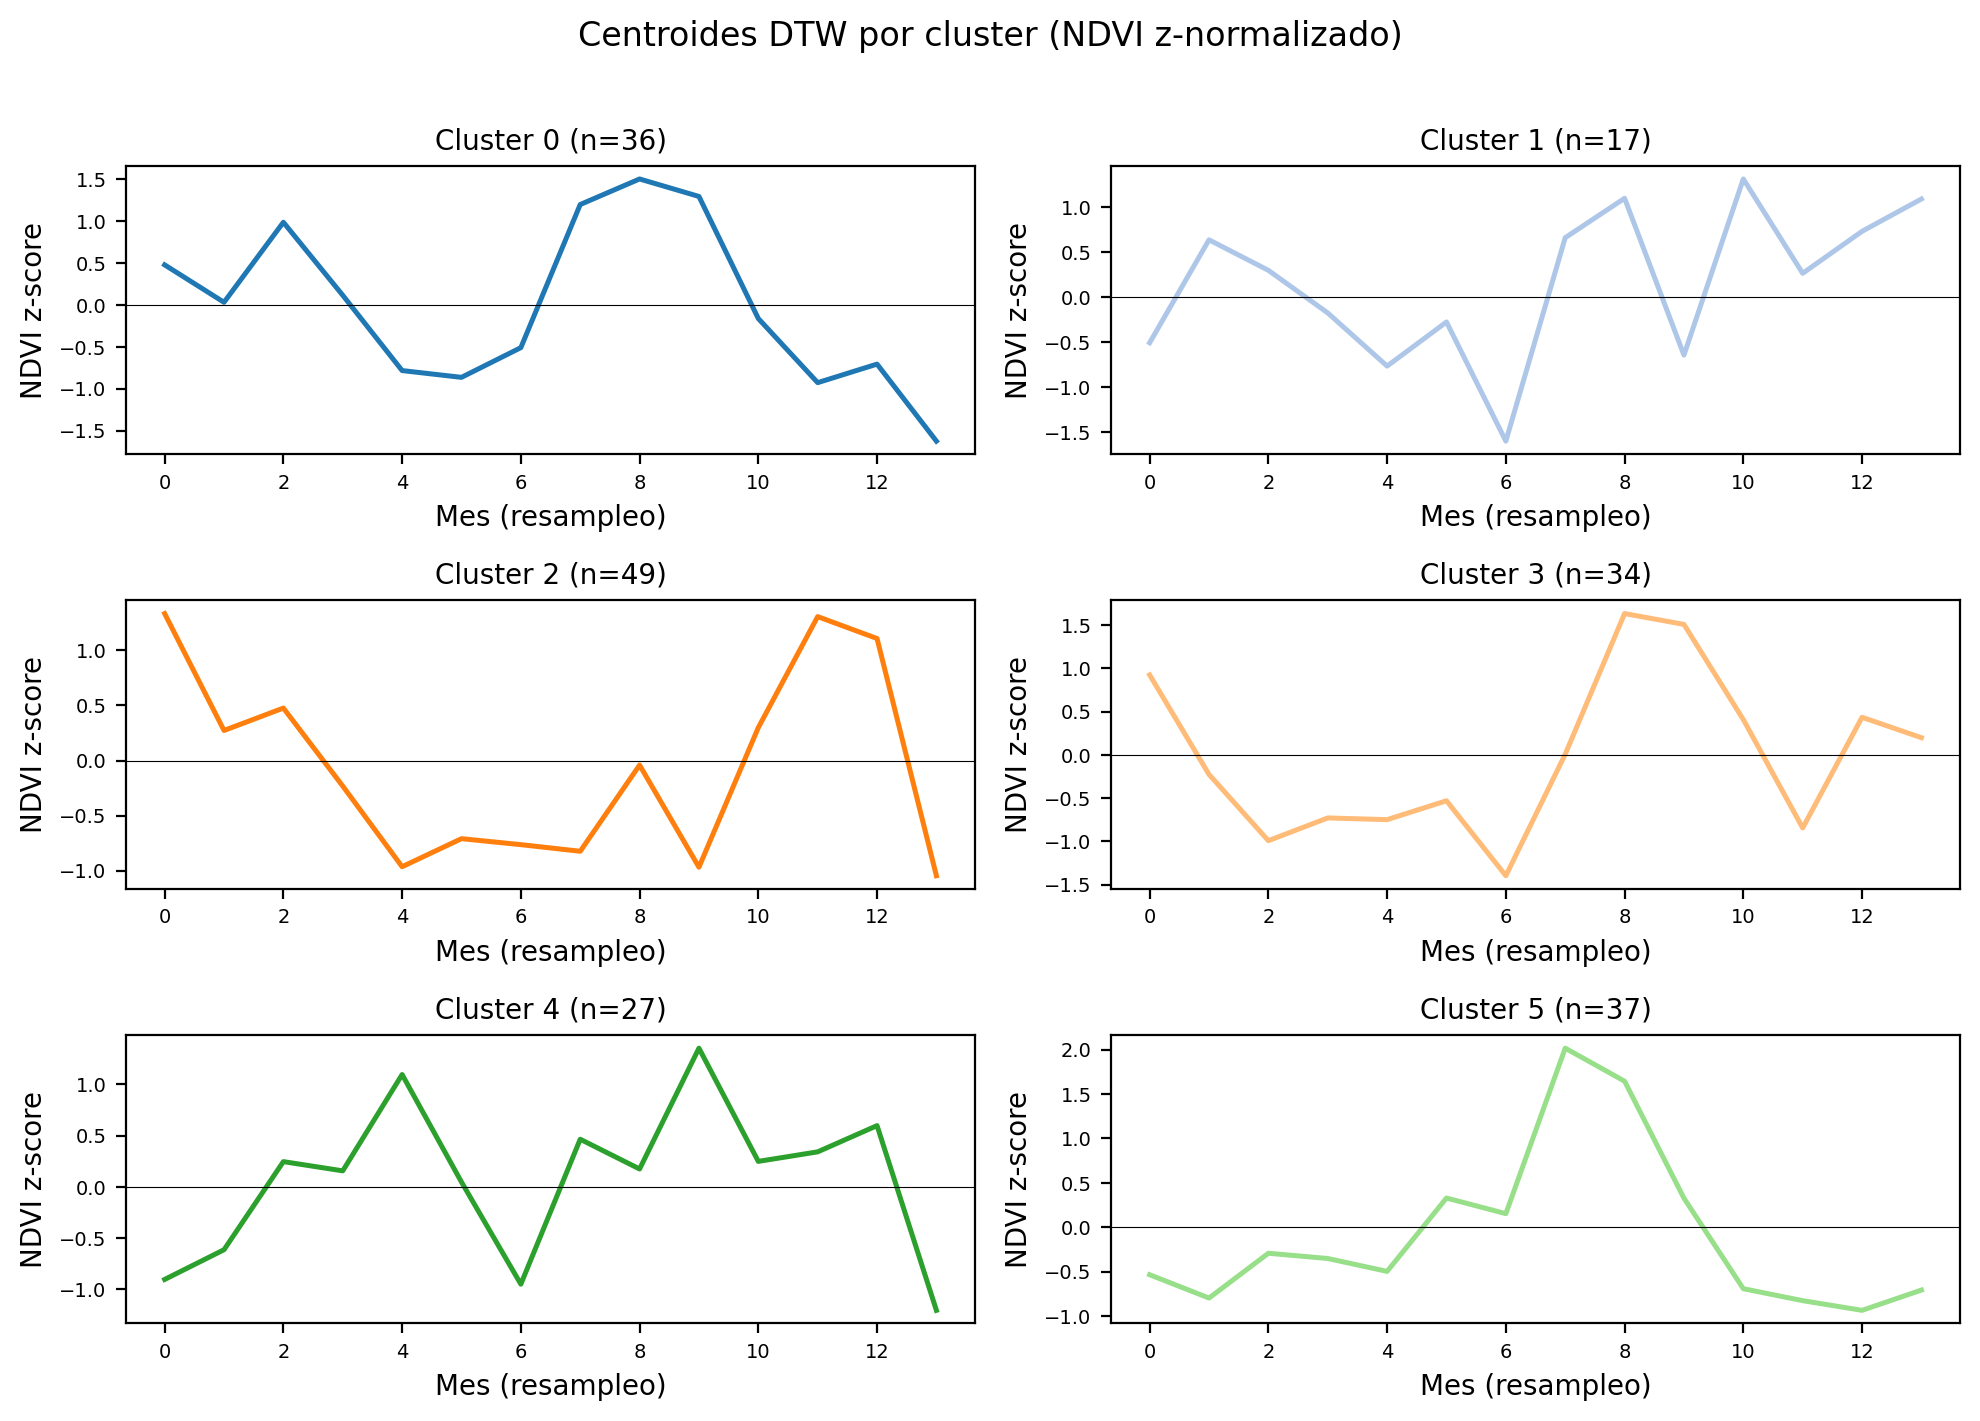

In [15]:
if not df_idx.is_empty() and "NDVI" in df_idx.columns:
    df_dtw_input = df_idx.rename({"NDVI": "ndvi", "date_parsed": "date_d"})
    df_clusters, km_model = dtw_cluster_temporal(
        df_dtw_input,
        n_clusters=n_dtw_clusters,
        parcel_col="parcel_id",
        date_col="date_d",
        series_col="ndvi",
        class_col="class_name",
        sakoe_chiba_radius=3,
        seed=seed,
    )
else:
    df_clusters = pl.DataFrame()
    km_model = None

if df_clusters.is_empty() or km_model is None:
    try:
        import tslearn  # noqa: F401
        tslearn_ok = True
    except ImportError:
        tslearn_ok = False
    if not tslearn_ok:
        display(Markdown(
            "> **Sección omitida**: la librería `tslearn` no está instalada en este entorno. "
            "Ejecuta `poetry install --with ml` para habilitar el agrupamiento DTW. "
            "El resto del notebook completa sin esta sección."
        ))
    else:
        display(Markdown("> No hay suficientes series para correr DTW con la configuración actual."))
    dtw_purity = 0.0
else:
    # Pureza ponderada: fraccion de la clase mayoritaria por cluster, ponderada
    # por tamano relativo. 1.0 = clusters monocromatucos por clase. 1/n_classes
    # ~ aleatorio.
    total = df_clusters.height
    purity_terms: list[float] = []
    for cid in df_clusters["cluster_id"].unique().to_list():
        sub = df_clusters.filter(pl.col("cluster_id") == cid)
        top_n = (
            sub.group_by("class_name").agg(pl.len().alias("n"))
            .sort("n", descending=True).head(1)["n"][0]
        )
        purity_terms.append((sub.height / total) * (top_n / sub.height))
    dtw_purity = float(sum(purity_terms))
    display(Markdown(
        f"**Clusters asignados a `{df_clusters.height:,}` parcelas**  \n"
        f"**Pureza promedio ponderada**: `{dtw_purity:.3f}` "
        f"_(1.0 = clusters monocromáticos por clase; ~0.06 = aleatorio con 16 clases)_"
    ))
    cross = (
        df_clusters.group_by(["cluster_id", "class_name"])
        .agg(pl.len().alias("n"))
        .sort(["cluster_id", "n"], descending=[False, True])
    )
    display(Markdown("**Tabla cruzada cluster × clase (top 25 filas):**"))
    display(cross.head(25))

dtw_centroids_plot(km_model, df_clusters, out_path=FIGURES / "sec8_dtw_centroids.png")
if km_model is not None:
    show_saved_png(
        FIGURES / "sec8_dtw_centroids.png",
        caption="Centroides DTW por cluster (forma temporal característica)",
    )

## Sección 9 — Precipitación ERA5 cruzada con NDVI anual (referencia, no concluyente)

PASTIS-R cubre **septiembre 2018 a noviembre 2019**, es decir aproximadamente 14 meses calendario que alcanzan dos años parciales (2018 y 2019). Esta cobertura **no permite calcular anomalías estadísticamente válidas**: la z-score por ROI requiere al menos 3 años con datos completos para que la desviación estándar tenga sentido, y el percentil del 25 % para marcar "año seco" con N=2 puntos es matemáticamente indefinido.

Mostramos el cruce **sólo como referencia metodológica** para el módulo de Feature Engineering cuando se concatenen series Sentinel-2 multi-anuales fuera de PASTIS-R (descarga vía CDSE). El plot dual-axis y los valores absolutos de precipitación ERA5 quedan poblados; la tabla de anomalía se omite porque sus columnas `ndvi_anomaly_z` y `is_dry_year` serían NaN/arbitrarias con N=2 años.

Requiere autenticación Google Earth Engine (`earthengine authenticate`). Cuando GEE no está disponible la celda lo informa y salta el plot sin error.

In [16]:
ee_ok = False
df_era5 = pl.DataFrame(schema={"year": pl.Int64, "roi_name": pl.Utf8, "precip_mm": pl.Float64})
df_ndvi_annual = pl.DataFrame(schema={"year": pl.Int64, "roi_name": pl.Utf8, "ndvi_max": pl.Float64})
if not patch_coords.is_empty():
    try:
        import ee  # type: ignore[import-untyped]
        from ml.ingest.gee_sampler import init_ee
        init_ee()
        ee_ok = True
    except Exception as exc:  # noqa: BLE001
        display(Markdown(f"> Sección ERA5 omitida: GEE no disponible (`{exc}`)"))
if ee_ok and not patch_coords.is_empty():
    lons = patch_coords["lon"].to_numpy()
    lats = patch_coords["lat"].to_numpy()
    bbox = [float(np.min(lons)), float(np.min(lats)), float(np.max(lons)), float(np.max(lats))]
    try:
        roi = ee.Geometry.Rectangle(bbox)  # type: ignore[name-defined]
        df_era5 = era5_annual_precip(roi=roi, years=era5_years, cache_path=CACHE, roi_name="pastis_bbox")
    except Exception as exc:  # noqa: BLE001
        display(Markdown(f"> `era5_annual_precip` falló: `{exc}`"))
if not df_idx.is_empty() and "NDVI" in df_idx.columns:
    df_ndvi_annual = (
        df_idx.with_columns(pl.col("date_parsed").dt.year().alias("year"))
        .group_by("year")
        .agg(pl.col("NDVI").max().alias("ndvi_max"))
        .with_columns(pl.lit("pastis_bbox").alias("roi_name"))
        .select(["year", "roi_name", "ndvi_max"])
    )
display(Markdown(
    f"**Filas ERA5**: `{df_era5.height}`  \n"
    f"**Filas NDVI anual**: `{df_ndvi_annual.height}`"
))

**Filas ERA5**: `3`  
**Filas NDVI anual**: `2`

**Valores absolutos por año (precipitación ERA5 + NDVI máximo anual):**

year,precip_mm,ndvi_max
i64,f64,f64
2018,835.878452,1.0
2019,904.301269,1.0


> N=2 años en PASTIS-R. La z-score de anomalía y el flag `is_dry_year` no son interpretables con este tamaño de muestra y se omiten.

**Precipitación ERA5 anual vs NDVI máximo anual (referencia metodológica, N=2 años)**

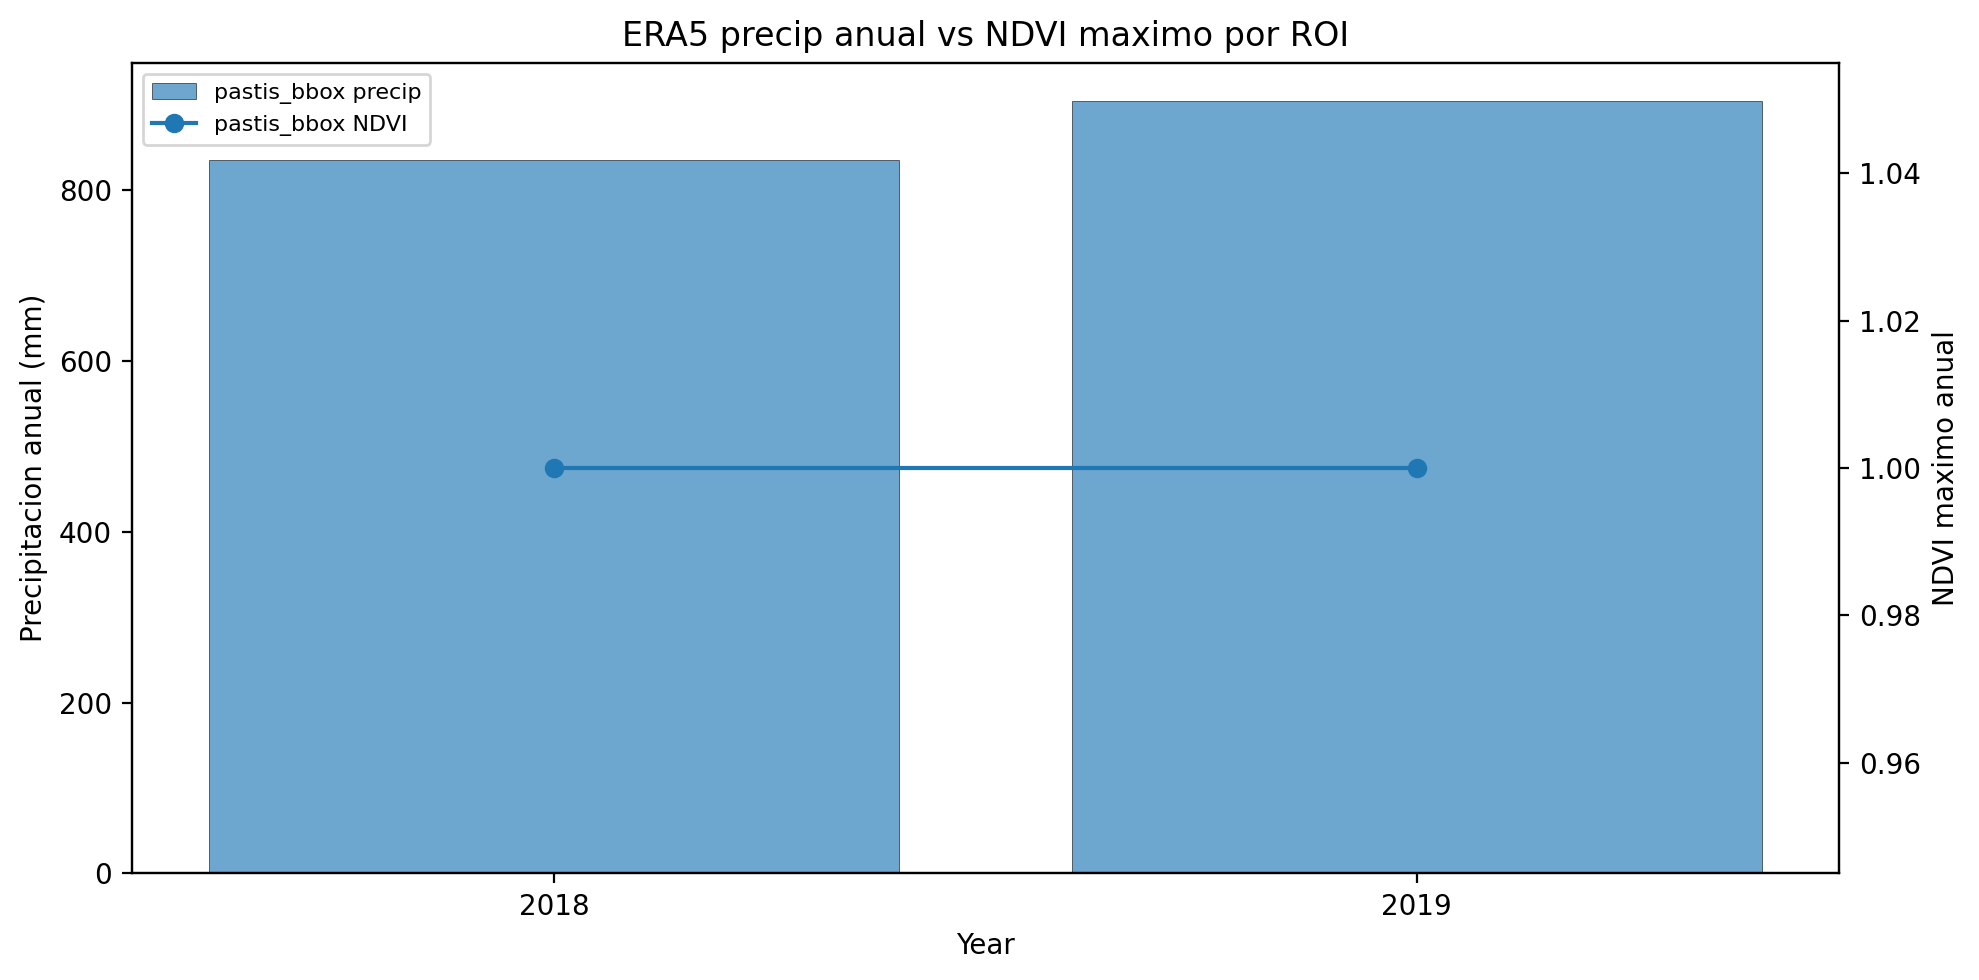

In [17]:
# df_anomaly se calcula y se conserva en memoria para el summary final, pero NO
# se muestra al lector: con N=2 anios la z-score es NaN y is_dry_year arbitrario.
df_anomaly = era5_ndvi_anomaly(df_era5, df_ndvi_annual)

if not df_era5.is_empty() and not df_ndvi_annual.is_empty():
    display(Markdown("**Valores absolutos por año (precipitación ERA5 + NDVI máximo anual):**"))
    display(
        df_era5.join(df_ndvi_annual, on=["year", "roi_name"], how="inner")
        .select(["year", "precip_mm", "ndvi_max"])
        .sort("year")
    )
    display(Markdown(
        "> N=2 años en PASTIS-R. La z-score de anomalía y el flag `is_dry_year` "
        "no son interpretables con este tamaño de muestra y se omiten."
    ))

dual_axis_precip_ndvi(df_era5, df_ndvi_annual, out_path=FIGURES / "sec9_era5_ndvi_dual_axis.png")
if not df_era5.is_empty() and not df_ndvi_annual.is_empty():
    show_saved_png(
        FIGURES / "sec9_era5_ndvi_dual_axis.png",
        caption="Precipitación ERA5 anual vs NDVI máximo anual (referencia metodológica, N=2 años)",
    )

## Conclusiones

### Qué encontramos

**La calidad del dato es el primer cuello de botella.** De 8 600 timesteps cargados, **545 (6.3 %) tienen alguna banda fuera del rango físico `[0, 1.5]`** después de escalar a reflectancia — son artefactos BOA (DN negativo tras corrección atmosférica) o pixels nubosos. Filtrar estos timesteps en lugar de clipearlos preserva la variabilidad real del NDVI: ahora `peak_ndvi_value` muestra distribución continua (0.81, 0.95, 0.97, ...) en lugar de saturarse a 1.0 en el 75 % de las parcelas como ocurría con el `clip_negative` previo. **Para el baseline, replicar esta máscara antes de cualquier cálculo de índice o feature temporal.**

**Las bandas Sentinel-2 son fuertemente redundantes entre sí.** En el conjunto unión de pares con correlación Pearson `|r| > 0.85` aparecen **19 pares únicos banda-banda** y **6 pares únicos índice-índice**, mientras que **ningún par banda-índice** cruza ese umbral (techo `r ≈ 0.80` en B04↔NDWI, por la no-linealidad inherente a `(a-b)/(a+b)`). El cuarteto {B07, B8A, B02, B03} forma un bloque casi perfecto: `B07↔B8A = 0.997`, `B02↔B03 = 0.996`. Lo mismo con el visible: B03/B04/B05 entre sí > 0.99.

**Los índices core también son redundantes.** NDVI↔NDRE = `0.974`, NDVI↔SAVI = `0.949`, NDRE↔SAVI = `0.945`, NDVI↔NDWI = `-0.959`. Del cuarteto {NDVI, NDRE, NDWI, SAVI} **basta uno** como representante; los cuatro miden esencialmente la misma señal con distintos signos y normalizaciones. NDMI usa B11 (SWIR) y aporta dimensión propia que el resto no captura.

**El VIF marca las 16 features para descarte** (`drop` o `dropped_near_perfect_corr`). EVI tiene el VIF más bajo del conjunto (`11.3`) seguido de NDMI (`15.7`), pero ambos superan el umbral convencional de 10. Esto significa que **ninguna feature aislada es ortogonal al resto** — para el baseline conviene aplicar PCA sobre el bloque de bandas o trabajar con un subset reducido aceptando colinealidad residual (NDVI + NDMI + un par de bandas SWIR).

**Las correlaciones banda × índice tienen un techo agronómico de ~0.80.** Los pares líderes (B04↔NDWI con `r = 0.80`, B12↔NDWI con `r = 0.74`, B12↔NDVI con `r = -0.73`) coinciden con la teoría: el rojo (B04) es absorbido por clorofila sana; el SWIR (B12) es sensible a estrés hídrico. Confirma que los índices están capturando estructura física, no ruido numérico.

**El mes del pico NDVI separa familias de cultivos.** Los ejemplos en la tabla de picos muestran: `Soft winter wheat` con picos en abril-mayo, `Corn` y `Beet` en agosto-septiembre, `Meadow` en septiembre-octubre, `Fruits/vegetables/flowers` distribuido. La feature `mes_pico` es por sí sola fuertemente discriminativa.

**El agrupamiento DTW con k=6 alcanza pureza `0.380`** sobre 12 clases mayoritarias presentes (vs ~`0.06` que daría asignación aleatoria con 16 clases). La separación más nítida emerge en cereales de invierno: aparece un cluster donde dominan `Soft winter wheat + Winter barley` con baja presencia de `Meadow`. El resto de clusters son mezclados — esperable porque PASTIS-R cubre sólo 14 meses y muchas clases (potato, beet, corn, rapeseed) tienen perfiles temporales similares en ese horizonte. Subir a k=8 fragmenta sin ganar interpretabilidad.

**La autocorrelación temporal es débil con esta cobertura.** Sólo `6.5 %` del total de pares `(parcela, lag≥1)` supera el umbral de Bartlett `±0.524` (para `n ≈ 14` observaciones mensuales por parcela). El lag más informativo es lag=1 con `22 %` de pares significativos — persistencia mes-a-mes, esperable en NDVI. Hay un repunte modesto en lag=4 (`8 %`) que sugiere un ciclo trimestral incipiente. **No hay señal anual interpretable**: necesitamos concatenar más años Sentinel-2 fuera de PASTIS-R para modelar estacionalidad con autocorrelación.

**ERA5 × NDVI con N=2 años es referencia metodológica, no concluyente.** PASTIS cubre sólo 2018 (parcial) y 2019 (parcial), lo que vuelve la z-score de anomalía indefinida (varianza con N=2 es trivial) y el flag `is_dry_year` arbitrario. La precipitación absoluta sí queda en el plot: `836 mm` en 2018, `904 mm` en 2019. Para usar este cruce en producción se requiere serie multianual de Sentinel-2 desde CDSE.

### Lo que sigue

1. **Aplicar la máscara de bandas inválidas como primer paso del Feature Engineering**: `compute_indices_subset(scale=1e-4, mask_invalid_band_range=(0.0, 1.5), clip_evi_range=(-1.0, 2.0))` debe replicarse 1:1 en el módulo del próximo avance, antes de cualquier cómputo de feature temporal o espectral.
2. **Colapsar a un set mínimo defendible**: `NDMI + NDVI + B12 + B08` cubre el espacio físico (humedad SWIR, vigor visible/NIR, dos bandas spectrales independientes). Aceptamos VIF residual; lo manejará la regularización del modelo. PCA sobre el bloque banda crudo es una alternativa razonable si el baseline lo soporta.
3. **Derivar features fenológicas explícitas**: `mes_pico_ndvi` (entera, 1-12), `valor_pico_ndvi` (ahora informativa porque ya no se satura), `distancia_mes_pico_a_mediana_de_clase` (continua) y `cluster_dtw_id` (categórica con k=6) entran como features adicionales.
4. **Resampleo mensual + Z-score por parcela** como pipeline temporal estándar antes de FFT, pendientes o integrales. El baseline debe usar exactamente el mismo resampleo que se usó aquí.
5. **Concatenar años Sentinel-2 fuera de PASTIS-R** (descarga directa desde CDSE) si se quiere modelar estacionalidad con ACF a lag 12, o si se quiere usar ERA5 × NDVI con N≥3 años para anomalía válida.

In [18]:
# Resumen final de la corrida
summary = {
    "patches_loaded": len(patch_ids_sample),
    "parcelas_pixel": df_idx.select("parcel_id").n_unique() if not df_idx.is_empty() else 0,
    "indices_computed": indices_present,
    "timesteps_validos": f"{n_after:,} / {n_before:,} ({pct_dropped:.1f}% descartados)",
    "pares_redundantes_pearson_gt_085": redundant.height if not redundant.is_empty() else 0,
    "features_vif_drop": (
        vif_df.filter(pl.col("status").is_in(["drop", "dropped_near_perfect_corr"])).height
        if not vif_df.is_empty() else 0
    ),
    "peaks_detected": df_peaks.height if not df_peaks.is_empty() else 0,
    "dtw_clusters_k": n_dtw_clusters,
    "dtw_parcelas_asignadas": df_clusters.height if not df_clusters.is_empty() else 0,
    "dtw_purity_ponderada": f"{dtw_purity:.3f}",
    "acf_pct_pares_significativos": f"{pct_global:.1f}%",
    "era5_anios_con_ndvi": df_ndvi_annual.height if not df_ndvi_annual.is_empty() else 0,
    "figures_dir": str(FIGURES.relative_to(REPO)),
}
df_summary = pl.DataFrame({"metric": list(summary.keys()), "value": [str(v) for v in summary.values()]})
display(Markdown("### Resumen de la corrida"))
display(df_summary)

### Resumen de la corrida

metric,value
str,str
"""patches_loaded""","""30"""
"""parcelas_pixel""","""200"""
"""indices_computed""","""['NDVI', 'NDWI', 'NDMI', 'EVI', 'SAVI', 'NDRE']"""
"""timesteps_validos""","""8,055 / 8,600 (6.3% descartados)"""
"""pares_redundantes_pearson_gt_085""","""50"""
"""features_vif_drop""","""16"""
"""peaks_detected""","""200"""
"""dtw_clusters_k""","""6"""
"""dtw_parcelas_asignadas""","""200"""
